==============================================================================================
# Practicum 5

==============================================================================================

## Delivery

Your overall grading will be penalized if the following requirements are not fulfilled:

- Implemented code should be commented exhaustively and in **English**. 

- The questions introduced in the exercises must be answered.

- Add title to the figures to explain what is displayed.

- Answers to questions also need to be in **English**.

- Make sure to print and plot exactly what it is indicated. If a reference image is provided, your output is expected to be exactly the same unless instructed differently. 

- The deliverable of both parts must be a file named **P5_Student1_Student2.zip** that includes:
    - The notebook P5_Student1_Student2.ipynb completed with the solutions to the exercises and their corresponding comments.
    - All the images used in this notebook (upload the ones that were not provided)
    
- It is required that your code can be run by us without need of any modification and without getting any errors.

- Use packages and solutions that were covered in your class and tutorials. If you are unsure about using a particular package, you should seek clarification from your instructor to confirm whether it is allowed.

- Please refrain from utilizing resources like ChatGPT to complete this lab assignment.


**Deadline: December 22th, 23:00 h**

==============================================================================================

This lab covers the following topics: 
* Gaussian filters
* Descriptors based on texture
* Distance between images and similarity search
* Face detection using:
    * Haar-like features
    * Adaboost
    * PCA



==============================================================================================
##  Image search using textures
==============================================================================================

#### Problem we want to solve
- Given a query image **$x$** and a set of images **$X$** we would like to retreive the most similar to **$x$** images from  **$X$**.



### Imports

In [1]:
%matplotlib inline
# GENERAL ONES FOR IMAGE ANALYSIS
import time
import scipy
import numpy as np
import skimage
from skimage import filters
from skimage import io
from skimage.color import rgb2gray, rgba2rgb
from skimage.util import img_as_ubyte, img_as_float
from skimage.transform import resize
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from time import time

### FACE DETECTION
from skimage.feature import haar_like_feature
from skimage.feature import haar_like_feature_coord
from skimage.feature import draw_haar_like_feature
from skimage.transform import integral_image

### FACE RECOGNITION
# Load the dataset
from sklearn.datasets import fetch_lfw_people 
# Classification and results
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report 

# Derivative of Gaussians aka Leung-Malik (LM) Filter Bank
We can apply a collection of multiple filters that we call a filter bank. Note that if we apply $D$ filters our feature vectors will be $D$ dimensional.

The following image shows a filter bank. In the filter bank we typically want filters to capture a combination of scales, orientations of different types of patterns. This particular filter bank is The Derivative-of-Gaussians or as known as Leung-Malik (LM) Filter Bank.

<img src="./images/filter_bank.png">


We import Leung-Malik filters as follows:

In [2]:
import LM_filters
filter_bank = LM_filters.makeLMfilters()
# NOTE: If this does not work, go to appendix for function code

LM filters imported, the shape of the filter bank is:  (49, 49, 48)


### Plotting all filters

Plot the created filters as images similar to the figure above.

In [3]:
help(LM_filters)

Help on module LM_filters:

NAME
    LM_filters - The Leung-Malik (LM) Filter Bank, implementation in python

DESCRIPTION
    T. Leung and J. Malik. Representing and recognizing the visual appearance of
    materials using three-dimensional textons. International Journal of Computer
    Vision, 43(1):29-44, June 2001.

    Reference: http://www.robots.ox.ac.uk/~vgg/research/texclass/filters.html

FUNCTIONS
    gaussian1d(sigma, mean, x, ord)

    gaussian2d(sup, scales)

    log2d(sup, scales)

    makeLMfilters()

    makefilter(scale, phasex, phasey, pts, sup)

DATA
    F = array([[[ 1.03689080e-070,  1.02118607e-118,  1....4237e-006,  3.3...

FILE
    /Users/mariovilar/Desktop/VA/P5/LM_filters.py




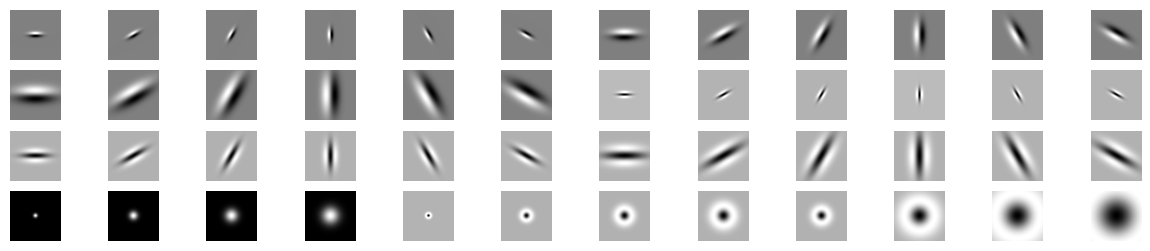

In [4]:
n_filters = filter_bank.shape[-1]
ncols = 12
nrows = n_filters // ncols
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(15,3))

k = 0
for i in range(nrows):
    for j in range(ncols):
        ax[i,j].imshow(filter_bank[:,:,k], cmap = 'gray')
        ax[i,j].axis("off")
        k += 1

## 1. Extracting a feature vector for an image

**1.1** Read the image ``/images/pizza.jpg``, and resize it to 240𝑥240 pixels. Then, convert the image to grayscale and visualize both, the RGB and the grayscale images.

In [5]:
pizza = io.imread('images/pizza.jpg')
pizza = resize(pizza, (240,240))
gray_pizza = rgb2gray(pizza)

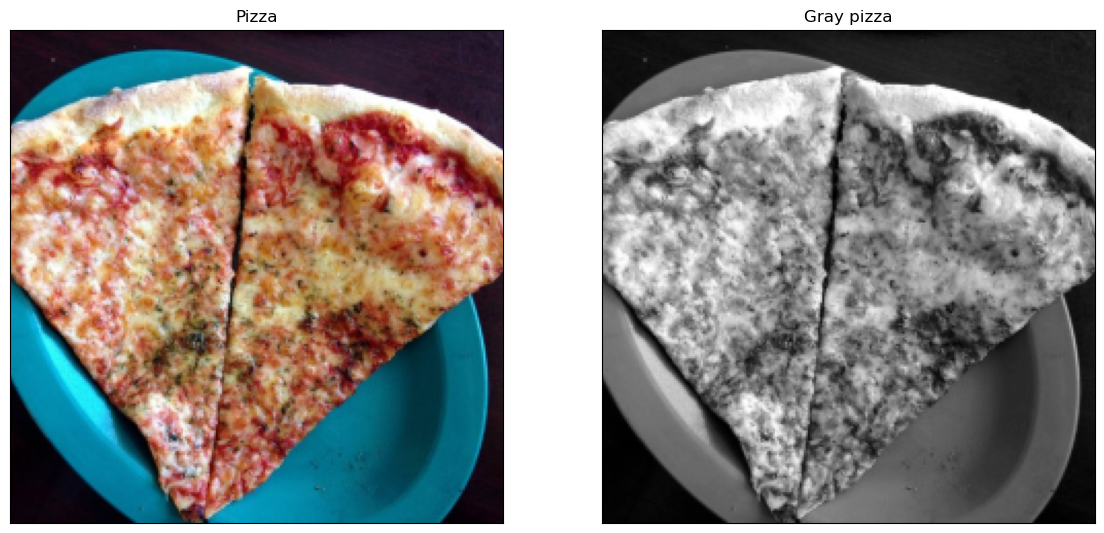

In [6]:
fig, axs = plt.subplots(ncols=2,figsize=(14,9))

axs[0].imshow(pizza)
axs[0].set_title('Pizza')

axs[1].imshow(gray_pizza, cmap='gray')
axs[1].set_title('Gray pizza')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

**1.2** Given $D=n\_{filters}$ filters from the filter bank and a single image `image`, make a function `get_image_features(image, filter_bank, n_filters)` that returns a feature vector of shape `n_filters`. The returned vector must contain at position $k$ the **mean of the absolute value of the convolved image** by filter $k$.

$$
\text{feat}(x) = \left( \text{mean}( |r_1|), \dots,\text{mean}(|r_D|) \right)
$$

Try the function with the previous image and print the feature vector.

**Hint**: The function should return a feature vector obtained by averaging each filter response on the image. Use a small number of filters to try your functions

In [7]:
abs(np.array([[-2,2,-1],[4,-4,3]]))

array([[2, 2, 1],
       [4, 4, 3]])

In [8]:
def get_image_features(image, filter_bank, n_filters):
    # Convolve the gray-scaled image with each filter in the bank
    features = np.zeros(n_filters)
    for i in range(n_filters):
        feat = scipy.ndimage.convolve(image, filter_bank[:, :, i])
        # mean of each features
        features[i] = np.mean(abs(feat))
    # return
    return features

In [9]:
## Try the function
im_features = get_image_features(gray_pizza, filter_bank, 6)
print(im_features, len(im_features))

[0.01601096 0.01450635 0.01425211 0.01591052 0.01726204 0.01750745] 6



**1.3** (Optional) Try ``get_image_features()`` using a different number of filters and other images (for instance ``/images/dog.jpg`` or ``/images/flower.jpg``)


In [10]:
dog = rgb2gray(io.imread('images/dog.jpg'))
flower = rgb2gray(io.imread('images/flower.jpg'))
n = [4, 5, 7, 10, 20]

for i, img in enumerate([dog, flower]):
    for j, n_filters in enumerate(n):
        im_features = get_image_features(img, filter_bank, 6)
        print(im_features[:5])

[0.00761028 0.00696873 0.00691349 0.00750343 0.00787936]
[0.00761028 0.00696873 0.00691349 0.00750343 0.00787936]
[0.00761028 0.00696873 0.00691349 0.00750343 0.00787936]
[0.00761028 0.00696873 0.00691349 0.00750343 0.00787936]
[0.00761028 0.00696873 0.00691349 0.00750343 0.00787936]
[0.00959117 0.00956867 0.00953494 0.0092982  0.00923549]
[0.00959117 0.00956867 0.00953494 0.0092982  0.00923549]
[0.00959117 0.00956867 0.00953494 0.0092982  0.00923549]
[0.00959117 0.00956867 0.00953494 0.0092982  0.00923549]
[0.00959117 0.00956867 0.00953494 0.0092982  0.00923549]


### Visualizing features

**1.4** Make a function `visualize_features(im,  filter_bank, n_filters=5)` that receives the `filter_bank`, an image `im` and an integer `n_filters`. 

The function  must make a plot of two rows containing in the first row, in position $k$, the image convolved by filter $k$. In the second row, in position $k$, the image of the k'th filter. The result for `n_filter=5` should look like 


<img src="./images/filters.png" >

**Hint**: Note that since at this moment we are focusing on the texture, we will not use the color of the images.

In [11]:
def visualize_features(im, filter_bank, n_filters=5):
    
    fig, axs = plt.subplots(ncols=n_filters, nrows=2, figsize=(15,6))
    # Convolve images with the filters.
    images = [scipy.ndimage.convolve(im, filter_bank[:,:, i]) for i in range(n_filters)]
    
    # Show in first row the convolved images and in the second one the filters used in each convolsion.
    for i in range(n_filters):
        axs[0,i].imshow(images[i], cmap='gray')
        axs[0,i].set_title(f"Filter {i+1}")
        axs[1,i].imshow(filter_bank[:, :, i], cmap='gray')
    
    plt.setp(axs, xticks=[], yticks=[]) # Off ticks
    plt.show()

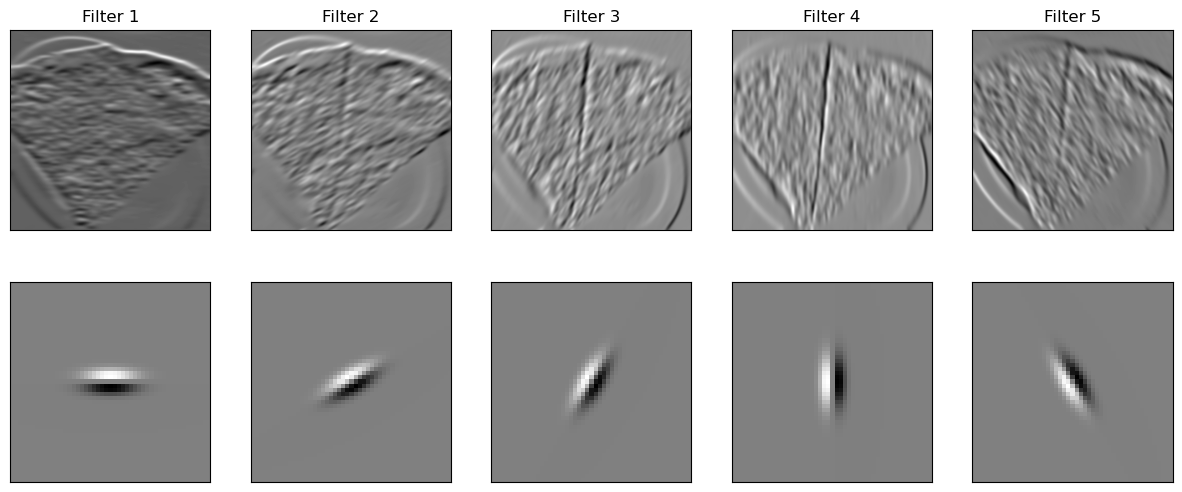

In [12]:
visualize_features(gray_pizza, filter_bank)

**1.5** (Optional) Try ``visualize_features()`` using a different number of filters and using another image (for instance ``/images/dog.jpg`` or ``/images/flower.jpg``)

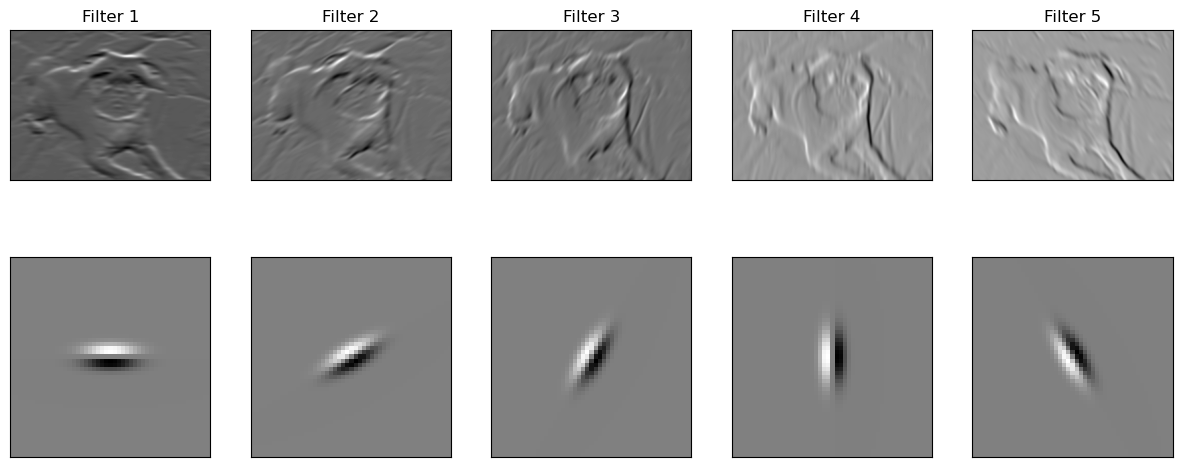

In [13]:
dog = rgb2gray(io.imread('images/dog.jpg'))
visualize_features(dog, filter_bank)

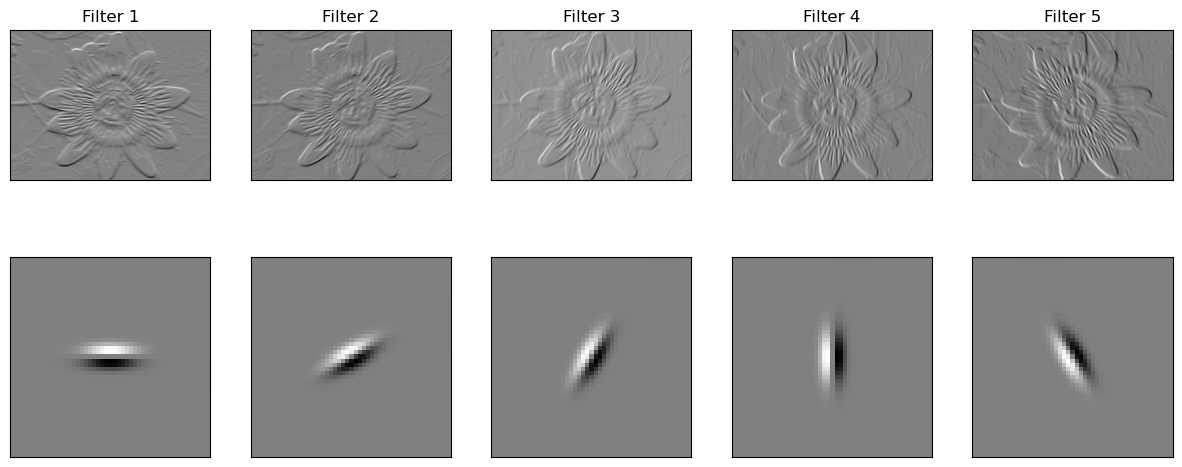

In [14]:
flower = rgb2gray(io.imread('images/flower.jpg'))
visualize_features(flower, filter_bank)

## 2 Load & resize the dataset

**2.1** Read all the images in the directories, resize them to 240x240 pixels and save the image in an array:

<ul>
    <li>./images/pizza/</li>
    <li>./images/flowers/</li>
    <li>./images/pets/</li>
    <li>./images/birds/</li>
    <li>./images/aircrafts/</li>
    <li>./images/cars/</li>
    <li>./images/skyscraper/</li>
    <li>./images/forest/</li>
</ul>

**Hint:** You have to create an array for each directory, which containts all the images belonging to that path.

In [15]:
def load_resize(path):
    collection = os.listdir(path)
    imgs = []
    for file in collection:
        img = io.imread(path + file)

        # If the image is RGBA we transform it to RGB
        if img.shape[-1] == 4:
            img = rgba2rgb(img)

        # If the image is RGB we transform it to gray
        if img.shape[-1] == 3:
            img = rgb2gray(img)
            
        img = resize(img, (240,240))
        imgs.append(img)
        
    return imgs

In [16]:
pizza_images = load_resize("./images/pizza/")
flowers_images = load_resize("./images/flowers/")
pets_images = load_resize("./images/pets/")
birds_images = load_resize("./images/birds/")
aircrafts_images = load_resize("./images/aircrafts/")
cars_images = load_resize("./images/cars/")
skyscraper_images = load_resize("./images/skyscraper/")
forest_images = load_resize("./images/forest/")

Visualize one image (the first) from each array. Use ``subplot`` to create a 3x1figure.

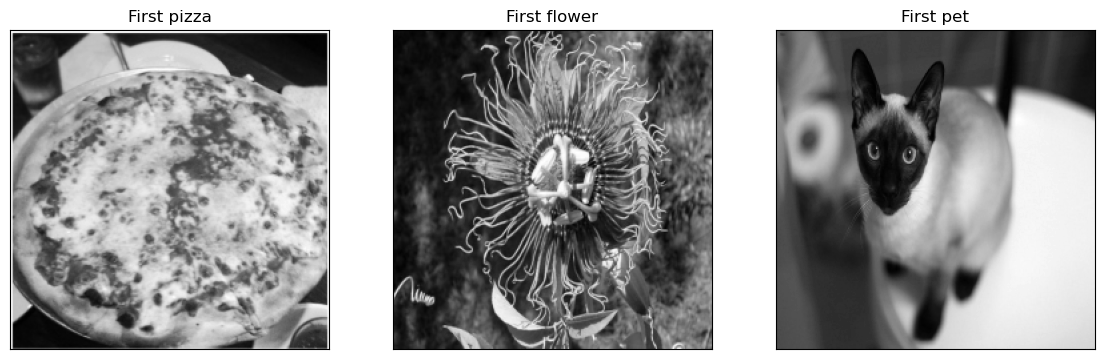

In [17]:
fig, axs = plt.subplots(ncols=3,figsize=(14,9))

axs[0].imshow(pizza_images[0], cmap='gray')
axs[0].set_title('First pizza')

axs[1].imshow(flowers_images[0], cmap='gray')
axs[1].set_title('First flower')

axs[2].imshow(pets_images[0], cmap='gray')
axs[2].set_title('First pet')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

How many images there are in **each** directory?

In [18]:
print(len(pizza_images))
print(len(flowers_images))
print(len(pets_images))

30
29
29


### Constructing the matrix of the feature vectors for all images

**2.2** Implement a function `get_dataset_features(all_images, filter_bank, n_filters=6)` that applies `get_image_features` to get a feature vector for each of the images in the union of the three datasets (fish and chips_images, pizza, paella). It must return a matrix containing at row $k$ feature vector for the input image $k$.

Try the function with the whole data set:

*all_images = pizza_images + flowers_images + pets_images + birds_images + aircrafts_images + cars_images + skyscraper_images + forest_images*

In [19]:
from scipy.ndimage import convolve

def get_dataset_features(all_images, filter_bank, n_filters):
    
    n_images = len(all_images)
    feature_vectors = np.zeros((n_images,n_filters))
    
    for i, img in enumerate(all_images):
        features = get_image_features(img, filter_bank, n_filters)
        feature_vectors[i] = features
        print(f"Image {i} is finished")
    
    return feature_vectors

In [20]:
all_images = pizza_images + flowers_images + pets_images + birds_images + cars_images + aircrafts_images + skyscraper_images + forest_images

In [21]:
feature_vectors = get_dataset_features(all_images, filter_bank, 6)

Image 0 is finished
Image 1 is finished
Image 2 is finished
Image 3 is finished
Image 4 is finished
Image 5 is finished
Image 6 is finished
Image 7 is finished
Image 8 is finished
Image 9 is finished
Image 10 is finished
Image 11 is finished
Image 12 is finished
Image 13 is finished
Image 14 is finished
Image 15 is finished
Image 16 is finished
Image 17 is finished
Image 18 is finished
Image 19 is finished
Image 20 is finished
Image 21 is finished
Image 22 is finished
Image 23 is finished
Image 24 is finished
Image 25 is finished
Image 26 is finished
Image 27 is finished
Image 28 is finished
Image 29 is finished
Image 30 is finished
Image 31 is finished
Image 32 is finished
Image 33 is finished
Image 34 is finished
Image 35 is finished
Image 36 is finished
Image 37 is finished
Image 38 is finished
Image 39 is finished
Image 40 is finished
Image 41 is finished
Image 42 is finished
Image 43 is finished
Image 44 is finished
Image 45 is finished
Image 46 is finished
Image 47 is finished
Im

Image 378 is finished
Image 379 is finished
Image 380 is finished
Image 381 is finished
Image 382 is finished
Image 383 is finished
Image 384 is finished
Image 385 is finished


Print the shape of `feature_vectors` as well as the features for image #3 (*i.e. all_images[2]*), image #33, and image #53, directly from the vector

In [22]:
print(feature_vectors.shape)
print(feature_vectors[2])
print(feature_vectors[32])
print(feature_vectors[52])

(386, 6)
[0.01450691 0.01364176 0.01136112 0.00994446 0.01059981 0.01312636]
[0.01182783 0.01109849 0.01227544 0.01370509 0.01402628 0.01300941]
[0.01554505 0.01436449 0.01379131 0.01428447 0.01563421 0.01622437]


### Visualizing the features of an image

**2.3** Define a function `visualize_features_imgs(im_index, feature_vector)` that given n different images, plots their features. Use different colors to distinguish the features of each image.
Choose 3 images on your choice and visualize the results.

<img src="./images/example_plot_features.jpg" >


In [23]:
def visualize_features_imgs(im_index, feature_vector):
    
    # Indices of the selected images
    ix, iy, iz = im_index

    # Extract the feature vectors
    x = feature_vectors[ix]
    y = feature_vectors[iy]
    z = feature_vectors[iz]

    # Index for the x-axis and y-axis
    ind = np.arange(0, feature_vectors.shape[1], dtype=int)
    yind = np.linspace(min(x.min(), y.min(), z.min()), max(x.max(), y.max(), z.max()), num=20)
    
    # Create the figure and adjust the size
    plt.figure(figsize=(10, 6))

    # Add the data lines
    plt.plot(ind, x, color='green', linestyle='-', linewidth=2, marker='o', label=f'Image {ix + 1}')
    plt.plot(ind, y, color='gray', linestyle='--', linewidth=2, marker='s', label=f'Image {iy + 1}')
    plt.plot(ind, z, color='skyblue', linestyle='-.', linewidth=2, marker='^', label=f'Image {iz + 1}')

    # Improve the axes
    plt.xlabel('Feature Index', fontsize=12)
    plt.ylabel('Feature Value', fontsize=12)
    plt.xticks(fontsize=10, ticks=ind, labels=ind+1)
    plt.yticks(fontsize=10, ticks=yind)

    # Add title and legend
    plt.title('Comparison of Feature Vectors', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='upper right')

    # Add gridlines for easier reading
    plt.grid(True, linestyle='--', alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()


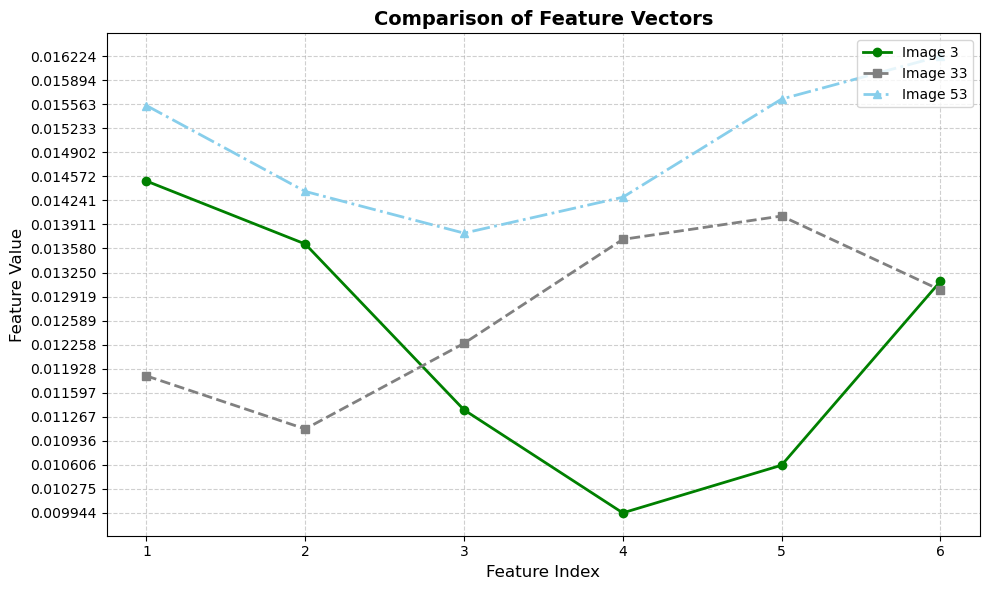

In [24]:
visualize_features_imgs([2,32,52], feature_vectors)

In [25]:
# Generalization of previous function

def visualize_features_imgs(im_index, feature_vectors):
    """
    Visualizes the feature vectors of a given set of images.
    
    Parameters:
    - im_index: List of image indices to compare.
    - feature_vectors: Array of feature vectors (shape: [n_images, n_features]).
    """
    # Ensure im_index is a list for iteration
    if not isinstance(im_index, (list, np.ndarray)):
        raise ValueError("im_index must be a list or array of indices.")
    
    # Extract the feature vectors of the selected images
    selected_features = [feature_vectors[idx] for idx in im_index]
    
    # Index for the x-axis
    ind = np.arange(0, feature_vectors.shape[1], dtype=int)
    
    # Determine y-axis limits based on all selected features
    y_min = min(np.min(features) for features in selected_features)
    y_max = max(np.max(features) for features in selected_features)
    yind = np.linspace(y_min, y_max, num=20)
    
    # Create the figure and adjust the size
    plt.figure(figsize=(10, 6))
    
    # Plot each feature vector with distinct styles
    colors = plt.cm.tab10.colors  # A colormap for distinct colors
    linestyles = ['-', '--', '-.', ':']  # A set of line styles to cycle through
    markers = ['o', 's', '^', 'd', 'x', '*', 'v', 'p']  # A set of markers to cycle through

    for i, (features, idx) in enumerate(zip(selected_features, im_index)):
        color = colors[i % len(colors)]
        linestyle = linestyles[i % len(linestyles)]
        marker = markers[i % len(markers)]
        plt.plot(ind, features, color=color, linestyle=linestyle, linewidth=2, 
                 marker=marker, label=f'Image {idx + 1}')
    
    # Improve the axes
    plt.xlabel('Feature Index', fontsize=12)
    plt.ylabel('Feature Value', fontsize=12)
    plt.xticks(fontsize=10, ticks=ind, labels=ind + 1)
    plt.yticks(fontsize=10, ticks=yind)

    # Add title and legend
    plt.title('Comparison of Feature Vectors', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='upper right')

    # Add gridlines for easier reading
    plt.grid(True, linestyle='--', alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()



# 3 Retrieving the most similar images

### Similarity search

Let us assume $f(x) \in \mathbb{R}^D$ represents a set of features for $x$. Given a query image $x$ and another image $x^m$ from the database, we can compute the distance between images as
$$
\text{distance}\left( f(x) , \, f(x^m) \right) = \| \text{feat}(x)  - \text{feat}(x^m)  \|_2 =  \sqrt{ \sum_{d=1}^\text{D} \left( f(x)_d - f(x^m)_d  \right)^2 }
$$

then we can find the closest image $x^{m^*}$ from the database to $x$ as $m^* =  \text{argmin}_{m} \{ \| \text{feat}(x)  - \text{feat}(x^m)  \|_2 \}$



**3.1** Implement a function `retrieve_images(im_features, feature_vectors, k=5)` to retrieve and visualize the `k` most similar images (according to the l2 norm) to `im` and the corresponding distances.

The input of this function need to be feature of the image of interest `im_features`, the whole data set features `feature_vectors`, and an integer value `k`, which defines the number of images.

The function should return the ordered vector of distances and the index of the closests images.

In [26]:
def retrieve_images(im_features, feature_vectors, k=5):
    
    # x gives us the number of images, y the number of features
    x, y = feature_vectors.shape
    closest = []
    
    # Compute distances between the model
    # and the features for each image
    for i in range(x):
        # Apply L2 norm between features
        dist = np.linalg.norm(feature_vectors[i] - im_features)  
        closest.append((dist, i))
    
    # Sort list by distance
    closest = sorted(closest, key=lambda x:x[0])
    distances = [distance for distance, _ in closest[:k]]
    closest_images = [image for _, image in closest[:k]]
    
    return closest_images, distances

Try your function using ``/images/pizza.jpg``.

In [27]:
pizza = rgb2gray(io.imread("./images/pizza.jpg"))
pizza = resize(pizza, (240,240))
im_features = get_image_features(pizza, filter_bank, 6)

In [28]:
# Try your function
closest, distances = retrieve_images(im_features, feature_vectors, k=5)
print(closest, distances)

[28, 368, 136, 52, 160] [np.float64(0.0), np.float64(0.0019309650593441663), np.float64(0.002684967039821944), np.float64(0.0027183969139036837), np.float64(0.0027588981583036654)]


In [29]:
im_features

array([0.01601096, 0.01450635, 0.01425211, 0.01591052, 0.01726204,
       0.01750745])

In [30]:
feature_vectors[28]

array([0.01601096, 0.01450635, 0.01425211, 0.01591052, 0.01726204,
       0.01750745])

**3.2** Write a function *show_closest_images(all_images, closest, distances)* to show the closest images and the corresponding distances. 

<img src="./images/indice.png" >


In [31]:
def show_closest_images(all_images, closest, distances):
    
    ncols = 5
    fig, axes = plt.subplots(len(closest) // ncols, ncols, figsize=(13, 6))
    ax = axes.ravel()
    
    for i in range(len(closest)):
        # Index of the image
        j = closest[i]
        ax[i].imshow(all_images[j], cmap='gray')
        ax[i].set_title("Distance: " + "{0:.7f}".format(distances[i]))
        ax[i].axis('off')
    
    plt.setp(axs, xticks=[], yticks=[]) # Off ticks
    plt.tight_layout()
    plt.show()

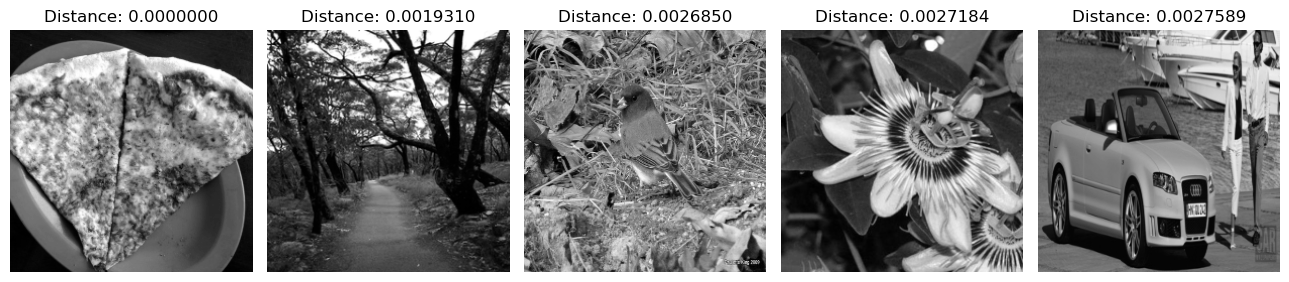

In [32]:
show_closest_images(all_images, closest, distances)

# 4 Compute the accuracy of the algorithm: given a query image. 

**4.1** Implement a function `accuracy(feature_vectors, class_labels, im_features, class_im,  k=5)`, which takes as input `feature_vectors`, the `class_labels` for the images (`0 = pizza`, `1 = flower`, `2 = pet`, `3 = bird`, `4 = car`, `5 = aircraft`, `6 = skycraper` and `7 = forest`), the number of images to retrieve `k`, a query image (i.e. the feature vector for the image of interest) and the class of the query image `class_im`. 

Returns as output the number of retrieved images that belong to class `class_im` divided by the total of images retrieved `k` (this is the accuracy).

**Hint**: Be careful to exclude the query image from the retrieved images (i.e. those cases in which `distance=0.0`)

In [33]:
help(np.full)

Help on function full in module numpy:

full(shape, fill_value, dtype=None, order='C', *, device=None, like=None)
    Return a new array of given shape and type, filled with `fill_value`.

    Parameters
    ----------
    shape : int or sequence of ints
        Shape of the new array, e.g., ``(2, 3)`` or ``2``.
    fill_value : scalar or array_like
        Fill value.
    dtype : data-type, optional
        The desired data-type for the array  The default, None, means
         ``np.array(fill_value).dtype``.
    order : {'C', 'F'}, optional
        Whether to store multidimensional data in C- or Fortran-contiguous
        (row- or column-wise) order in memory.
    device : str, optional
        The device on which to place the created array. Default: None.
        For Array-API interoperability only, so must be ``"cpu"`` if passed.

        .. versionadded:: 2.0.0
    like : array_like, optional
            Reference object to allow the creation of arrays which are not
            Num

In [34]:
# Define a dictionary mapping category names to their respective labels
categories = {
    "pizza": pizza_images,
    "flowers": flowers_images,
    "pets": pets_images,
    "birds": birds_images,
    "cars": cars_images,
    "aircrafts": aircrafts_images,
    "skyscraper": skyscraper_images,
    "forest": forest_images,
}

# Generate class labels dynamically
class_labels = np.concatenate([
    np.full(len(images), label)  # Create an array filled with the label
    for label, images in enumerate(categories.values())
])

In [35]:
def accuracy(feature_vectors, class_labels, im_features, class_im, k=5):
    
    closest, distances = retrieve_images(im_features, feature_vectors, k)
    
    # Remove img with distance equals to 0 (query image), if found
    dist = np.array(distances)
    idx = np.where(dist == 0)
    
    if np.size(idx) != 0:
        dist = np.delete(dist, idx)
        k -= np.size(idx)
        closest = np.delete(closest, idx)
    
    # Count number of hits
    count = 0
    for index in closest:
        if class_labels[index] == class_im: 
            count +=1
            
    return count / k

In [36]:
print("acc:", accuracy(feature_vectors, class_labels, im_features, 0, 5))

acc: 0.0


Compute the accuracy with k=10 with the previous images. Does the accuracy match the images retrieved from the previous exercise?

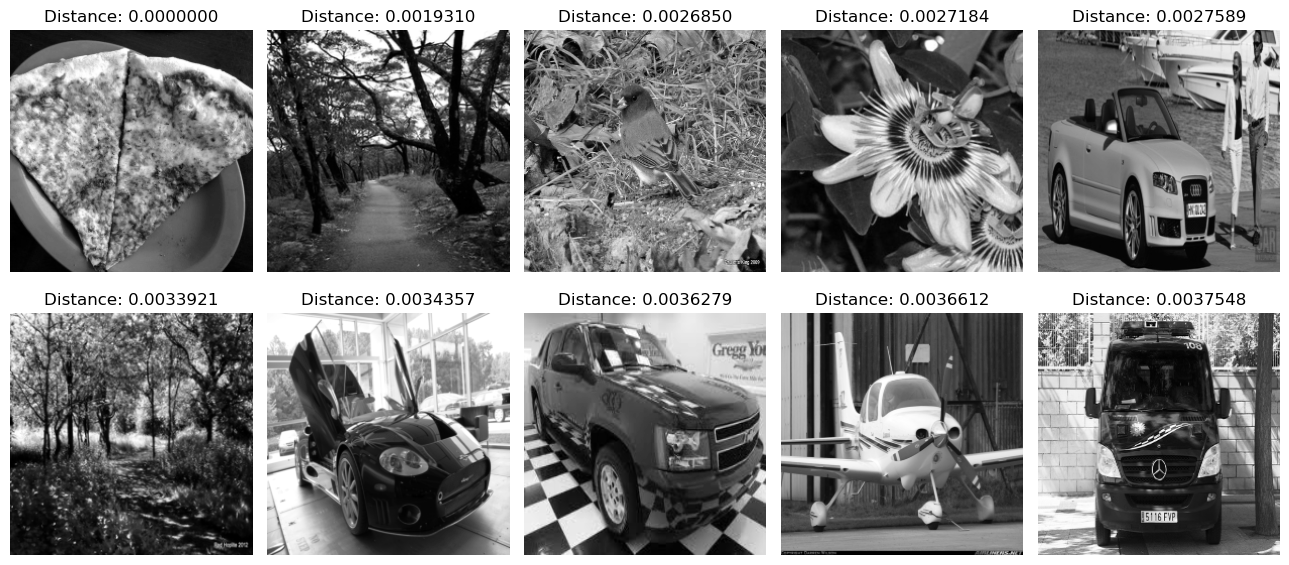

In [37]:
# Try your function
closest, distances = retrieve_images(im_features, feature_vectors, k=10)
show_closest_images(all_images, closest, distances)

In [38]:
print(closest, distances)
print("acc:", accuracy(feature_vectors, class_labels, im_features, 0, 10))

[28, 368, 136, 52, 160, 334, 187, 155, 253, 212] [np.float64(0.0), np.float64(0.0019309650593441663), np.float64(0.002684967039821944), np.float64(0.0027183969139036837), np.float64(0.0027588981583036654), np.float64(0.0033920817530940844), np.float64(0.0034356867849850226), np.float64(0.003627856668798591), np.float64(0.003661245554253347), np.float64(0.0037548235757669454)]
acc: 0.0


### Feature normalization

**4.3** As you can see in exercise 2.4, some features are higher than the rest and, therefore, they are "more important" during the image retrieving.

Normalize each feature between **[0,1]** using the minimum and the maximum values obtained from `feature_vectors`. Note that we need to use these values to normalize `im_features`.

* Plot the new features of an image, using `visualize_features_imgs()`. 
* Then, show the 5 closest images (use show_closest_images) from `im_features`
* Compute the accuracy. 

**Is there any difference? Do we obtain the same images than previously?**

In [39]:
feat_min, feat_max = np.min(feature_vectors), np.max(feature_vectors)
normalized_features = (feature_vectors - feat_min) / (feat_max - feat_min)
normalized_im = (im_features - feat_min) / (feat_max - feat_min)
print("feature_vectors", normalized_features.min(), normalized_features.max())
# Remember we are computing im_features from a pizza
print("im_features:", normalized_im.min(), normalized_im.max())

feature_vectors 0.0 1.0
im_features: 0.46364128386861664 0.581637926971983


A linear transformation (we are substracting and dividing by two scalars) modifies the distance value, but the "order" is preserved, i.e. first image is still closer than the second, the third, etc. Note that the distance hasa increased by more than 10 times in every case!

[28, 368, 136, 52, 160] [np.float64(0.0), np.float64(0.06999186954325028), np.float64(0.09732224923995846), np.float64(0.09853398498538468), np.float64(0.10000203734638684)]


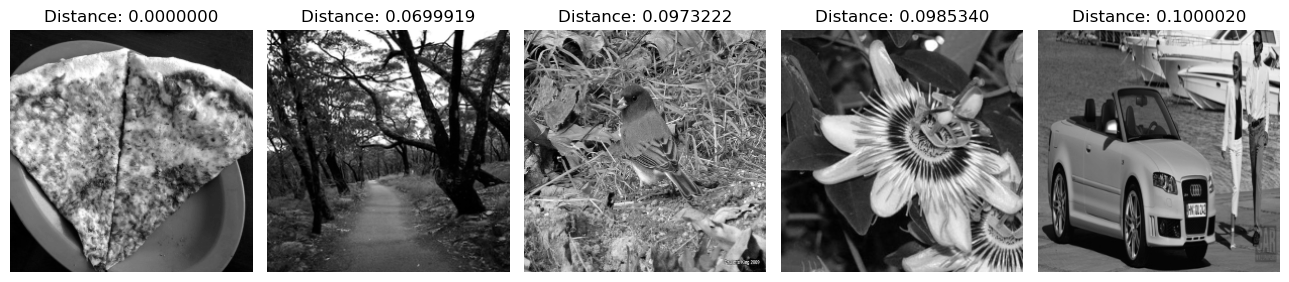

In [40]:
# Try your function
closest, distances = retrieve_images(normalized_im, normalized_features, k=5)
print(closest, distances)
show_closest_images(all_images, closest, distances)

# 5 Image retrieval based on texture and color. 

**5.1** Make a function ` lm_features_rgb(rgb_image, n_bins=12)`  that returns the features based on a color descriptor (using histograms, similar to what it was performed in the **Deliverable 3 - video segmentation**). 

**Hint:** Consider each bin from each channel as a feature, create a vector with all the features together. 

In [41]:
def load_resize_rgb(path):
    collection = os.listdir(path)
    imgs = []
    for file in collection:
        img = io.imread(path + file)

        # If the image is RGBA we transform it to RGB
        if img.shape[-1] == 4:
            img = rgba2rgb(img)
        
        # We cannot work with B&W images when we are working with color
        if img.shape[-1] != 3:
            continue
        
        img = resize(img, (240,240))
        imgs.append(img)
        
    return imgs

In [42]:
def get_image_features_rgb(image, filter_bank, n_filters):
    
    # Convolve the gray-scaled image with each filter in the bank
    features = np.zeros(n_filters)
    for i in range(n_filters):
        feat = scipy.ndimage.convolve(image, filter_bank[:, :, i])
        # mean of each features
        features[i] = np.mean(abs(feat))
    # return
    return features


def lm_features_rgb(rgb_image, n_bins=12):
    
    # We need the filter bank to use get_image_features
    bank = LM_filters.makeLMfilters()
    
    # We define the matrix
    features_for_im = np.zeros((n_bins, 3))
    
    # Extract the features of every channel of the image
    r = get_image_features_rgb(rgb_image[:,:,0], bank, n_bins)
    g = get_image_features_rgb(rgb_image[:,:,1], bank, n_bins)
    b = get_image_features_rgb(rgb_image[:,:,2], bank, n_bins)
    
    # And concatenate them
    features_for_im = np.concatenate((r, g, b))
        
    return features_for_im

In [43]:
# Try your function
pizza = io.imread("./images/pizza.jpg")
pizza = resize(pizza, (240,240))
print("PIZZA", pizza.dtype, pizza.shape)

# Take less than 12 bins for speedness
lm_rgb_features = lm_features_rgb(pizza, 6)
print(len(lm_rgb_features))

PIZZA float64 (240, 240, 3)
18



## Apply the function to all the images in the dataset

**5.2** Using ` lm_features_rgb` build the features of all the datapoints in  `all_images` and save them in `lm_dataset_features`.

In [44]:
pizza_rgb_images = load_resize_rgb("./images/pizza/")
flowers_rgb_images = load_resize_rgb("./images/flowers/")
pets_rgb_images = load_resize_rgb("./images/pets/")
birds_rgb_images = load_resize_rgb("./images/birds/")
aircrafts_rgb_images = load_resize_rgb("./images/aircrafts/")
cars_rgb_images = load_resize_rgb("./images/cars/")
skyscraper_rgb_images = load_resize_rgb("./images/skyscraper/")
forest_rgb_images = load_resize_rgb("./images/forest/")
all_rgb_images = pizza_rgb_images+flowers_rgb_images+pets_rgb_images+birds_rgb_images+aircrafts_rgb_images+cars_rgb_images+skyscraper_rgb_images+forest_rgb_images

In [45]:
from scipy.ndimage import convolve

def get_dataset_features_rgb(all_images, filter_bank, n_bins):
    
    n_images = len(all_images)
    feature_vectors = np.zeros((n_images, n_bins * 3))
    
    for i, img in enumerate(all_images):
        features = lm_features_rgb(img, n_bins)
        feature_vectors[i] = features
        print(f"Image {i} is finished")
    
    return feature_vectors

In [46]:
%%time 
'''
Solution
'''
# Take less than 12 bins for speedness
lm_dataset_features = get_dataset_features_rgb(all_rgb_images, filter_bank, 6)

Image 0 is finished
Image 1 is finished
Image 2 is finished
Image 3 is finished
Image 4 is finished
Image 5 is finished
Image 6 is finished
Image 7 is finished
Image 8 is finished
Image 9 is finished
Image 10 is finished
Image 11 is finished
Image 12 is finished
Image 13 is finished
Image 14 is finished
Image 15 is finished
Image 16 is finished
Image 17 is finished
Image 18 is finished
Image 19 is finished
Image 20 is finished
Image 21 is finished
Image 22 is finished
Image 23 is finished
Image 24 is finished
Image 25 is finished
Image 26 is finished
Image 27 is finished
Image 28 is finished
Image 29 is finished
Image 30 is finished
Image 31 is finished
Image 32 is finished
Image 33 is finished
Image 34 is finished
Image 35 is finished
Image 36 is finished
Image 37 is finished
Image 38 is finished
Image 39 is finished
Image 40 is finished
Image 41 is finished
Image 42 is finished
Image 43 is finished
Image 44 is finished
Image 45 is finished
Image 46 is finished
Image 47 is finished
Im

## Compute the accuracy of the method using `lm_features_rgb`

**5.3** Compute the accuracy of the retrieved images using the features that contain color information. Show the 4 closest images to the query images in the `lm_rgb` space with the function built before.

Is the accuracy higher? Please, comment the results.

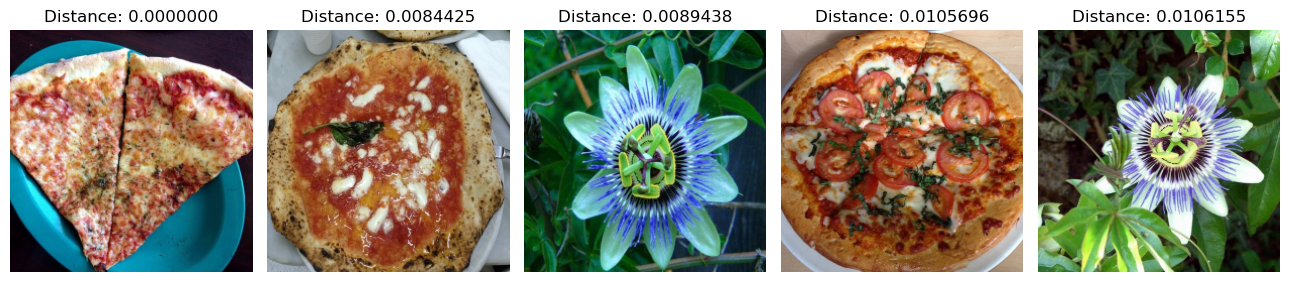

acc: 0.5


In [47]:
closest, distances = retrieve_images(lm_rgb_features, lm_dataset_features, k=5)
show_closest_images(all_rgb_images, closest, distances)
print("acc:", accuracy(lm_dataset_features, class_labels, lm_rgb_features, 0, 5))

Yes, accuracy is much higher. We can see that half of the closest images are, in fact, pizzas. By comparing B-W images instead of RGB, we chop everything into one channel, losing a great deal of information. In RGB, every one of the three channels is compared separately. Distances and time complexity increase because histograms are concatenated, i.e. we use much more data.

==============================================================================================
## Haar-like features applied for face detection
==============================================================================================

### What is a Haar-like feature?

Haar-like feature descriptors were successfully used to implement the first real-time face detector. In this laboratory we will see an example illustrating the extraction, selection, and classification of Haar-like features to detect faces vs. non-faces.

Documentation [Haar-like feature skimage](https://scikit-image.org/docs/0.14.x/auto_examples/xx_applications/plot_haar_extraction_selection_classification.html)

Haar-like features are features extracted from the images to recognize objects. These features are normally used in face recognition. The key to face recognition is to detect the relevant features of humans such as eyes, lips, or nose. 


<img src="images/haar-like.PNG" width=400, height=400>

Try to guess where in the face image we expect to detect an edge, line or another facial feature and what would be the most appropriate Haar-feature for them? 

<img src="images/haar-like1.PNG" width=500, height=500>


A real application would be:

<img src="images/face.PNG" width=300, height=300>


To describe the face, we can apply convolutions with Haar features.

### 6. Building integral image and Haar-like features

Compute all the Haar-like features (we can define up to 16000 million masks), can be a slow process. To compute it faster, we are going to use the integral images (instead of convolutions). It is very useful because we are able to save all the sums and substrations of image rectangles to avoid computing all the features every time.

When creating an Integral Image, we need to create a Summed Area Table. What does represent any point (x,y) in this table?

<img src="images/integral_image.PNG" width=250, height=250>

An example :

<img src="images/integral_image1.PNG" width=400, height=400>

To easy the computation of Haar features, the integral image must have an additional row and column full of zeros (first row and first column). Why?

**Answer**: To compute the sum of pixel intensities in a rectangular region, you use the values at the corners of the rectangle in the integral image. If you compute the sum of a region touching the edges of the image, such as the first row or column, some terms would refer to invalid indices. Adding an extra row and column of zeros ensures that these terms evaluate to 0 automatically.

**6.1** Build a function `to_integral_image` that computes the integral image of an input (2D) array. The integral image must have an additional row and column full of zeros (first row and first column).
Make sure that the values of the integral image are correct.

Try your function using a `5x5` random grayscale image. Visualize both the original random image and the integral one. Refrain from using built-in functions that already do the integral, compute it yourself. 

In [48]:
def to_integral_image(img):
    
    # integral image must have an additional row and column full of zeros
    h, w = img.shape
    integral_image = np.zeros((h + 1, w + 1))
    integral_image[1:,1:] = img
    
    for i in range(1, h+1):
        for j in range(1, w+1):
            integral_image[i,j] = np.sum(img[:i,:j]) 
    
    return integral_image

In [49]:
# Visualizing results on a random grayscale image
random_img = np.random.rand(5,5)
integral_img = to_integral_image(random_img)

To make sure that the values of the integral image are correct, compute the following tests:

 - `img_array.sum() == ii_img_array[-1,-1]`
 - `img_array[0,:].sum() == ii_img_array[1,-1]`

In [50]:
assert random_img.sum() == integral_img[-1,-1]
assert random_img[0,:].sum() == integral_img[1,-1]

**6.2** Let's check in real images. Choose an image from the directory ``./faces``, visualize both the original and the integral image, and make the same test that in the previous question.

Here is an example (you don't have to pick this image, you can do it at random):
<img src="images/integral_image_example.jpg" width=500, height=250>

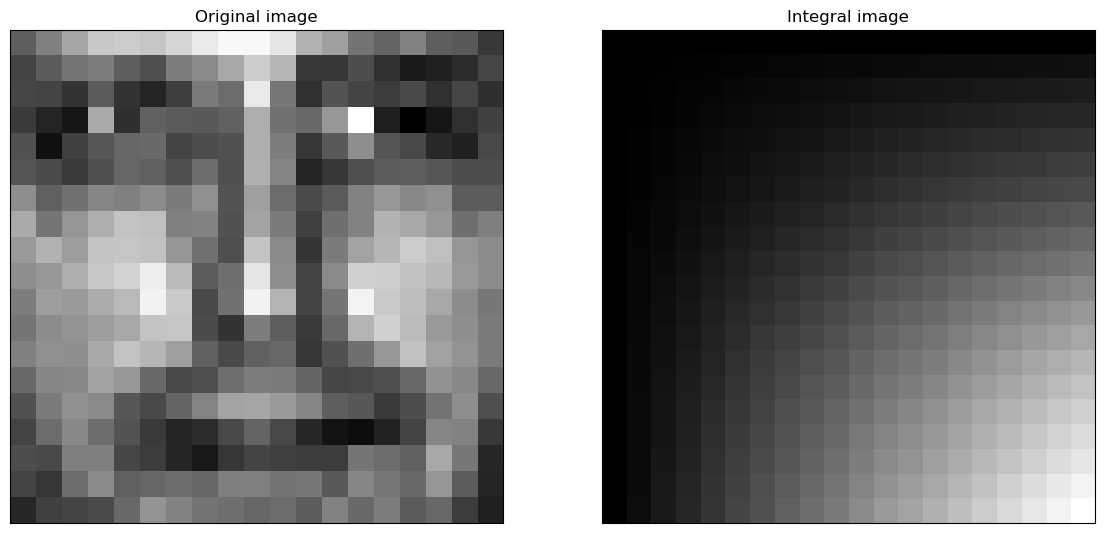

In [51]:
face = io.imread('./images/faces/face00001.png')
integral_face = to_integral_image(face)

fig, axs = plt.subplots(ncols=2,figsize=(14,9))

axs[0].imshow(face, cmap='gray')
axs[0].set_title('Original image')

axs[1].imshow(integral_face, cmap='gray')
axs[1].set_title('Integral image')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

**6.3:** Alternatively to your own function, you can use the ``integral_image()`` function from ``skimage.transform``. Compare (numerically) the result obtained using your funtion and that obtained using the function provided by skimage (no need to provide a written answer here, just make sure you are obtain same results).

In [52]:
help(skimage.transform.integral_image)

Help on function integral_image in module skimage.transform.integral:

integral_image(image, *, dtype=None)
    Integral image / summed area table.

    The integral image contains the sum of all elements above and to the
    left of it, i.e.:

    .. math::

       S[m, n] = \sum_{i \leq m} \sum_{j \leq n} X[i, j]

    Parameters
    ----------
    image : ndarray
        Input image.

    Returns
    -------
    S : ndarray
        Integral image/summed area table of same shape as input image.

    Notes
    -----
    For better accuracy and to avoid potential overflow, the data type of the
    output may differ from the input's when the default dtype of None is used.
    For inputs with integer dtype, the behavior matches that for
    :func:`numpy.cumsum`. Floating point inputs will be promoted to at least
    double precision. The user can set `dtype` to override this behavior.

    References
    ----------
    .. [1] F.C. Crow, "Summed-area tables for texture mapping,"
          

In [53]:
skintegral = skimage.transform.integral_image(face)
print("INFINITY NORM:", np.linalg.norm(skintegral - integral_face[1:,1:], ord=np.inf))

INFINITY NORM: 0.0


Every norm, in particular infinity norm, checks that if $\|A\|_\infty=0$, then $A=0$. So if $\|I_1-I_2\|_\infty=0$, then $I_1=I_2$, i.e. in the cell above both calculations of integral images yield the same result.

## Haar-like features

Let's use the [haar_like_feature()](https://scikit-image.org/docs/0.14.x/api/skimage.feature.html#skimage.feature.haar_like_feature) function from skimage. Check the parameters and the returned value of the ``function haar_like_feature()`` before continuing and **NOTE** that we must use the integral image (**not the real image**) in this function.

*skimage.feature.haar_like_feature(int_image, rint, cint, widthint, heightint, feature_type=None, feature_coord=None)*



###  Extract features

**6.4** Define a function ``extract_feature_image(image, feature_type, feature_coord=None)`` to obtain the Haar-like features, using a given type of features ``feature_types``, from an image. The aim of this function is as simple as to join both `to_integral_image()` and `haar_like_feature()`functions.

Try your function using the choosing image from *1.4*. You should obtain a feature vector. Print the vector shape.

**Note:** You can give an array with a set of feature types to the `haar_like_feature()` function and it will compute all the corresponding features. We **do not** need to give each time only one feature.


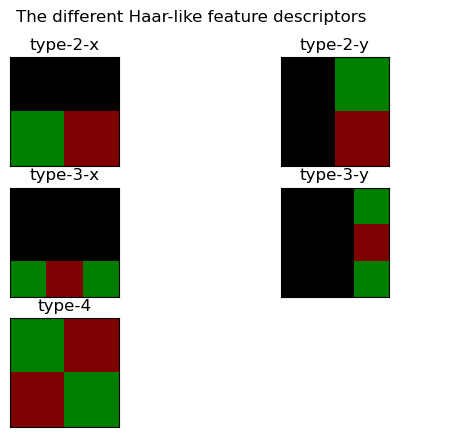

In [54]:
feature_types = ['type-2-x', 'type-2-y',
                 'type-3-x', 'type-3-y',
                 'type-4']

zeros = [
    np.zeros((2, 2)),
    np.zeros((2, 2)),
    np.zeros((3, 3)),
    np.zeros((3, 3)),
    np.zeros((2, 2)),
]

fig, axs = plt.subplots(3, 2)
for ax, img, feat_t in zip(np.ravel(axs), zeros, feature_types):
    coord, _ = haar_like_feature_coord(img.shape[0], img.shape[1], feat_t)
    haar_feature = draw_haar_like_feature(
        img, 0, 0, img.shape[0], img.shape[1], coord, max_n_features=1, rng=0
    )
    ax.imshow(haar_feature)
    ax.set_title(feat_t)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('The different Haar-like feature descriptors')
plt.axis('off')
plt.show()

In [55]:
def extract_feature_image(image, feature_type, feature_coord=None):
    
    # Compute integral image and pass parameters to haar_like_feature function
    x, y = image.shape
    integral = to_integral_image(image)
    return haar_like_feature(integral, 0, 0, x, y, feature_type, feature_coord)

In [56]:
features = extract_feature_image(face, 'type-2-x')
print("Vector shape (one feature_type): ", features.shape)

features = extract_feature_image(face, feature_types)
print("Vector shape (all feature types): ", features.shape)

Vector shape (one feature_type):  (17100,)
Vector shape (all feature types):  (63960,)


**6.5** Plot a Haar-like feature on an image:

To visualize Haar-like features on an image, we need the fuctions, provided by skimage, ``haar_like_feature_coord()``, which computes the coordinates of Haar-like features, and ``draw_haar_like_feature()``, used to visualize that features.

Before continuing, please, **check the online documentation of the two functions**

- [*haar_like_feature_coord(width, height, feature_type=None)*](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.haar_like_feature_coord)

- [*draw_haar_like_feature(image, r, c, width, height, feature_coord, color_positive_block=(1.0, 0.0, 0.0), color_negative_block=(0.0, 1.0, 0.0), alpha=0.5, max_n_features=None, random_state=None)*](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.draw_haar_like_feature)

Define a function ``plotFeatures``  to visualize Haar-like features on an images, given a array of feature types ``feature_types``. The aim of this exercise is, similarly to the previous one, to merge both `haar_like_feature_coord()` and `draw_haar_like_feature()` functions. Try your own function using the choosing image from *1.4* as follows:

<img src="images/image1.png" width=600, height=400>

*Note that there are multiple features and therefore your results might not exactly match this example, depending on your selection.*

In [57]:
# We have to plot over an image, must be a function parameter
def plotFeatures(image, feature_type, feature_coord=None):
    
    # Create the figure and axes
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    
    # Flatten the axes array for easy iteration
    axes = axes.ravel()

    for i, feature_type in enumerate(feature_types):
        if i >= len(axes):
            break
        
        # Get the feature coordinates
        feature_coord, _ = haar_like_feature_coord(
            image.shape[0], image.shape[1], feature_type
        )

        # Draw the feature on the image
        img = draw_haar_like_feature(
            image, 0, 0, image.shape[0], image.shape[1], feature_coord, max_n_features=1
        )

        # Plot the result
        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(feature_type)

    fig.suptitle('The Most Important Features', fontsize=16)
    plt.setp(axes, xticks=[], yticks=[]) # Off ticks
    plt.tight_layout()
    plt.show()

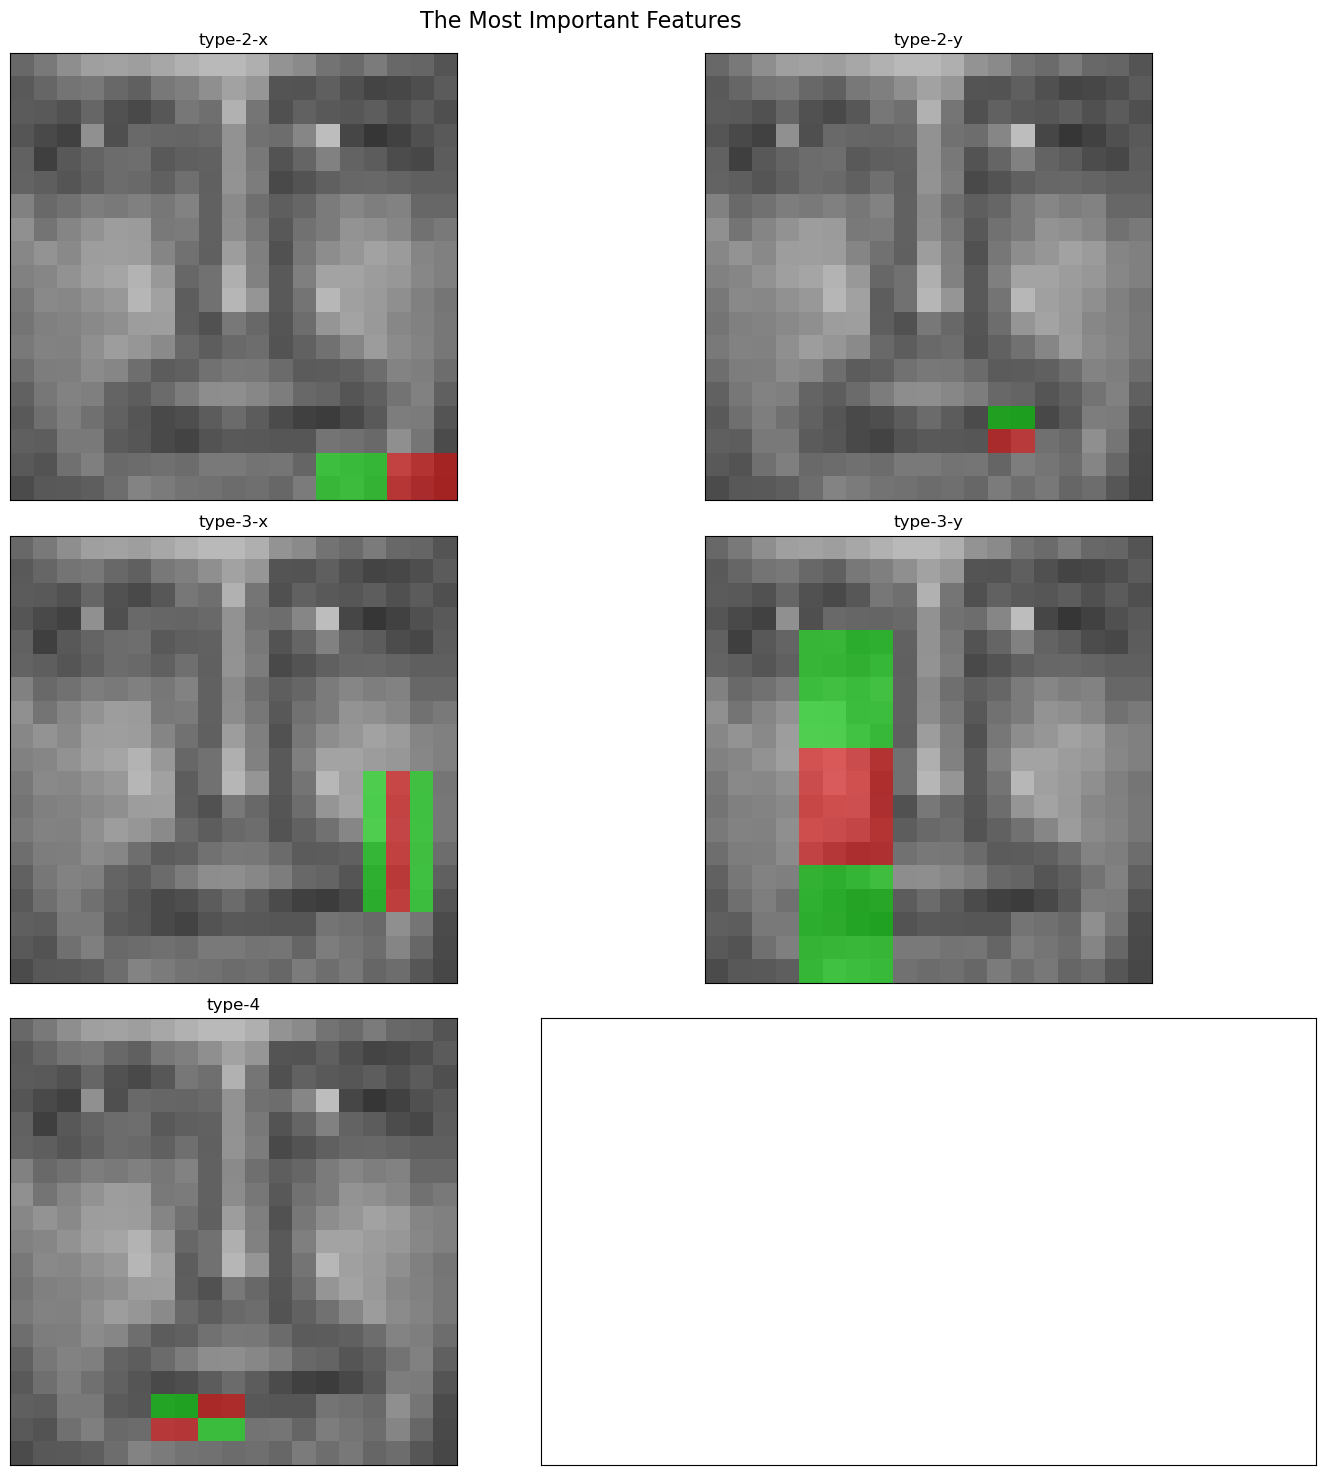

In [58]:
plotFeatures(face, feature_types)

## 7 Face detection using an Adaboost

**7.1** Read all the images from the directories ``./faces`` and ``./nonfaces`` and build an array with the all the features (use the `built extract_feature_image` for this). 

Futhermore, build the class labels vector ``y`` with the label of all the images. Make sure both, images and labels are numpy array objects.

#### Note
Same as `load_resize()`, but we do not resize. We could have passed a boolean `resize=True/False` into the parameters of `load_resize()`. It is much cleaner than to create a new function, but we opted for this solution based on comodity. 

In [59]:
def load_faces(path):

    collection = os.listdir(path)
    imgs = []
    
    for file in collection:
        img = io.imread(path + file)

        # If the image is RGBA we transform it to RGB
        if img.shape[-1] == 4:
            img = rgba2rgb(img)
        
        # We cannot work with B&W images when we are working with color
        if img.shape[-1] == 3:
            img = rgb2gray(img)

        imgs.append(img)
        
    return imgs

In [60]:
faces_images = load_faces("./images/faces/")
nonfaces_images = load_faces("./images/nonfaces/")
all_faces = faces_images + nonfaces_images

# Define a dictionary mapping category names to their respective labels
faces_categories = {
    "faces": faces_images,
    "non-faces": nonfaces_images,
}

# Generate class labels dynamically
y = np.concatenate([
    np.full(len(faces), label)
    for label, faces in enumerate(faces_categories.values())
])

print(y.shape)

(68,)


In [61]:
# build an array with all the features 
X = []
for i, image in enumerate(all_faces):
    X.append(extract_feature_image(image, feature_types))

**7.2** Using the ``train_test_split()`` function from `sklearn.model_selection`, divide the dataset into *train* and *test* sets. The test size must be the 30% (i.e. 0.3) of the whole dataset.

[*sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)*](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

Print the size of your images train and test set. 

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3)

**7.3** Train an Adaboost classifier using `AdaBoostClassifier()`from `sklearn.ensemble`.

[*sklearn.ensemble.AdaBoostClassifier(n_estimators=50, learning_rate=1.0)*](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

What is an Adaboost? How it works?

**Answer**: From `skimage` documentation, "AdaBoost classifier is a meta-estimator that begins by fitting a classifier on the original dataset and then fits additional copies of the classifier on the same dataset but where the weights of incorrectly classified instances are adjusted such that subsequent classifiers focus more on difficult cases". In other words, it combines the predictions of multiple "weak learners" (usually simple models like decision stumps) to create a "strong learner" capable of making highly accurate predictions.

In [63]:
from sklearn.ensemble import AdaBoostClassifier

In [64]:
clf = AdaBoostClassifier(n_estimators=50, learning_rate=1.0)
clf.fit(X_train, y_train)

AdaBoostClassifier()

**7.4** Evaluate the accuracy of the Adaboost classifier using the *predict* and *score* methods of the classifier. Make sure to use your test set for this. What are these methods doing?

In [65]:
result = clf.predict(X_test)
acc = clf.score(X_test, y_test)
print("Result: ", result)
print("Accuracy: ", acc)

Result:  [0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0]
Accuracy:  0.8571428571428571


Change the parameter ``n_estimators`` and see what happens to the test set accuracy. Does the performance increased or decreased?

Try at least 3 different values of `n_estimators`

In [66]:
%%time
estimators = [15, 25, 85, 100]
max_estimator, max_acc = 0, 0

for est in estimators:
    
    clf = AdaBoostClassifier(n_estimators=est, learning_rate=1.0)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    
    if acc > max_acc:
        max_acc = acc
        max_estimator = est

print(f"Max accuracy (n_estimators {max_estimator}):", max_acc)

Max accuracy (n_estimators 15): 0.9047619047619048
CPU times: user 1min 41s, sys: 822 ms, total: 1min 42s
Wall time: 1min 42s


**Answer**: Increasing the number of estimators (from a very small value) improves performance as the model combines more weak learners for better decision boundaries, but after a certain point adding more estimators may result in overfitting. So: 

- For $n_{\text{estimators}}$ too small, underfitting (and thus, lower accuracy).
- For $n_{\text{estimators}}$ too big, overfitting (and thus, same or lower accuracy).

**Note**: keep in mind that we use a strict inequality (i.e. accuracy must be strictly greater than actual max accuracy). If `n=100` has the same accuracy than previous `n`'s, we will discard it. Evidently so, because it is more time consuming than smaller `n`'s. 

**7.5 (Optional)** The method ``feature_importances_`` of the Adaboost is giving the importance of the features. Implement a function to visualize the 10 most important features of the model. 

**Solution**: from `AdaBoost` documentation, 
> The higher, the more important the feature. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.
>
> *Warning: impurity-based feature importances can be misleading for high cardinality features (many unique values).*

So `feature_importances_` gives us a score of the importance of the feature which we now should plot.

In [67]:
def plot_top_features(image, model, feature_types, n=10):
    
    # Extract feature importances
    importances = model.feature_importances_

    # Get the indices of the top N features
    idx = np.argsort(importances)[::-1][:n]
    x,y = image.shape
    feature_coord, _ = haar_like_feature_coord(x, y, feature_types)

    # Plot the top N features    
    ncols = 5
    fig, axes = plt.subplots(n // ncols, ncols, figsize=(13, 6))
    ax = axes.ravel()
    
    for i in range(n):
        # Index of the image
        img = draw_haar_like_feature(image, 0, 0, x, y, [feature_coord[idx[i]]])
        ax[i].imshow(img)
        ax[i].axis('off')
        
    plt.suptitle("Most important features")
    plt.setp(ax, xticks=[], yticks=[]) # Off ticks
    plt.tight_layout()
    plt.show()

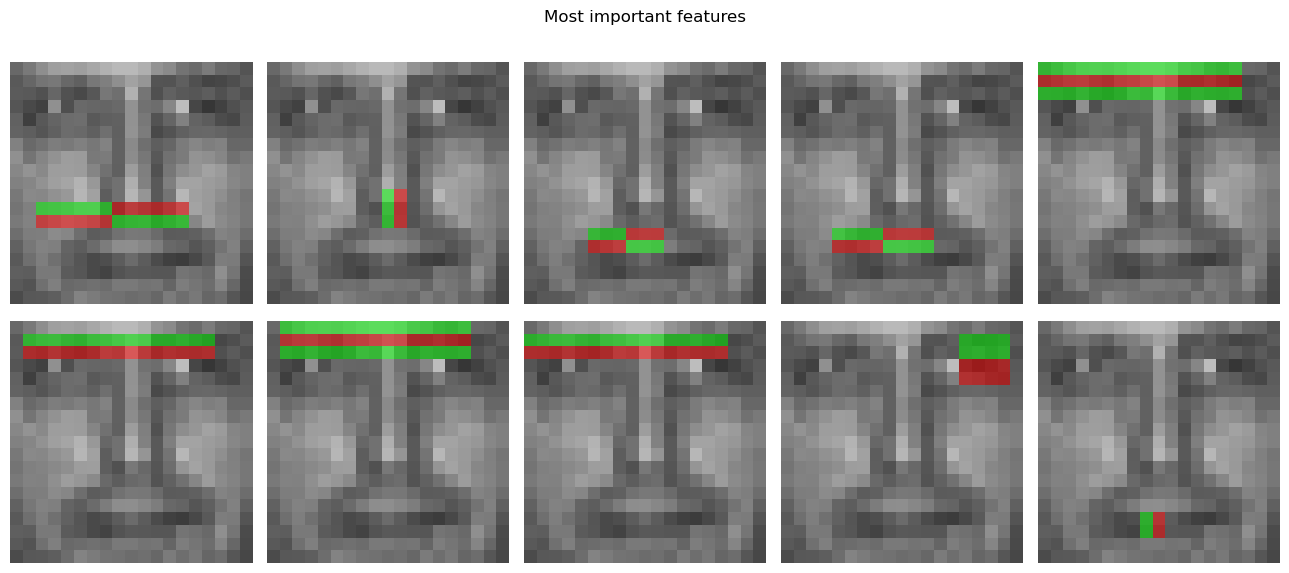

In [68]:
clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0)
clf.fit(X_train, y_train)

plot_top_features(face, clf, feature_types, 10)

==============================================================================================
## Principal Component Analysis (PCA) applied for face recognition
==============================================================================================

### Dimensionality and redundancy

Imagine we have a dataset with 100x100 pixel images, it means we have 10000 dimensions. We want to construct a low-dimensional linear subspace that best explains the variation in the set of face images (**Eigenfaces space**)

<img src="images/subspace.PNG" width=200, height=200>

Each image has m rows and n columns and defines a vector of (mxn) elements. We need to choose the most valuable pixels in order to avoid compute all dimensions. 

<img src="images/feature_vector.PNG" width=800, height=300>

We look for a transformation of the original space to a smaller (M << (mxn)) where faces are represented with their coordinates in this new space R.

To reduce the dimensionality retaining the information necessary to classify and recognize, we are going to use the **Eigenfaces method** 

### How to build a reduced space?

To build this new space, we are going to use the **Principal Component Analysis**. Given a large space, the PCA looks for the minimum number of axes that best represents the variation of the data.

<img src="images/pca.PNG" width=400, height=400>

The eigenvectors of the covariance matrix define the axis of maximum variance and the eigenvalues give a measure of the variance of the data. 

1. Construct the vector in the (m x n)-dimensional space R given M images of size (m x n).

2. Compute the mean image 

<center>
$\overline{X}=\frac{1}{M}\sum_{i=1}^{M} X_i$
</center>

3. Construct the covariance matrix. Due to $A \times A^T$ is too large, instead of using $A \times A^T$ to compute its eigenvectors, we are going to compute the eigenvectors of $A^T \times A$.

<img src="images/covariance_image.PNG" width=500, height=200>

4. Extract the eigenvectors (the base of the new space) and their eigenvalues and project faces in the new space to apply the classifier (knn)


## 8. Load and prepare data for PCA

Let's use the [Labeled Faces in the Wild (LFW)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html) people dataset (classification).

Face dataset features:

- Classes: 5749

- Samples total: 13233

- Dimensionality: 5828

- Features: real, between 0 and 255


*sklearn.datasets.fetch_lfw_people(data_home=None, funneled=True, resize=0.5, min_faces_per_person=0, color=False, slice_=(slice(70, 195, None), slice(78, 172, None)), download_if_missing=True, return_X_y=False)*



*Please, check the parameters and returned value by ``lethc_lfw_people()`` before continuing.*

**8.1** Load the dataset, obtaining only those cases where there are, **at least, 100 images**. Check the final number of images, image shapes and labels of the images.

*Hint: There is a parameter to set the minimum number of faces per person to load in the dataset function*

In [69]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)

# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

In [70]:
print(lfw_people['target'])

[2 3 1 ... 4 2 4]


In [71]:
print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)
print("Labels of the images", target_names)

Total dataset size:
n_samples: 1140
n_features: 1850
n_classes: 5
Labels of the images ['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']


**8.2** Plot an image frome each example, with its name as the title of the image.

<img src="images/example.png" width=500, height=200>

In [72]:
results = []
for i in range(n_classes):
    # Select one image, for example the first one to match the given images
    ocurrences = np.where(lfw_people.target == i)
    results.append(lfw_people.images[ocurrences[0][0]])

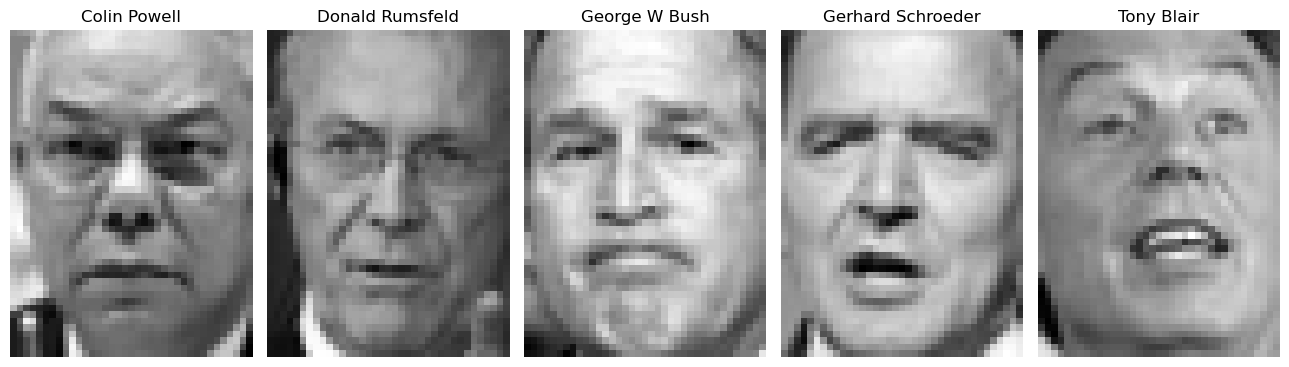

In [73]:
fig, axes = plt.subplots(1, len(results), figsize=(13, 6))
ax = axes.ravel()

for i, image in enumerate(results):
    ax[i].imshow(image, cmap="gray")
    ax[i].set_title(target_names[i])
    ax[i].axis('off')

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.tight_layout()
plt.show()

**8.3** Divide the dataset into train and test set (0.7/0.3). Print the size of train and test image sets.

Hint: use the train_test_split function.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3)

## Compute PCA

[*class sklearn.decomposition.PCA(n_components=None, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', random_state=None)*](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA)

The principal components measure deviations about this mean along orthogonal axes.

**8.4** Create a PCA object, using the training set and 150 components. 

*Consider that PCA requires the data to be reshaped into 2 dimensions: number of observations x number of pixels*

In [75]:
n_components = 150

print(
    "Extracting the top %d eigenfaces from %d faces" % (n_components, X_train.shape[0])
)
t0 = time()
pca = PCA(n_components=n_components, svd_solver="auto", whiten=True).fit(X_train)
print("done in %0.3fs" % (time() - t0))

Extracting the top 150 eigenfaces from 798 faces
done in 0.163s


Plot the accumated variance of the components. 

**Hint:** Use `explained_variance_ratio_` to return the variance explained, plot this.

<img src="images/explained_variance_example.jpg" width=400, height=400>

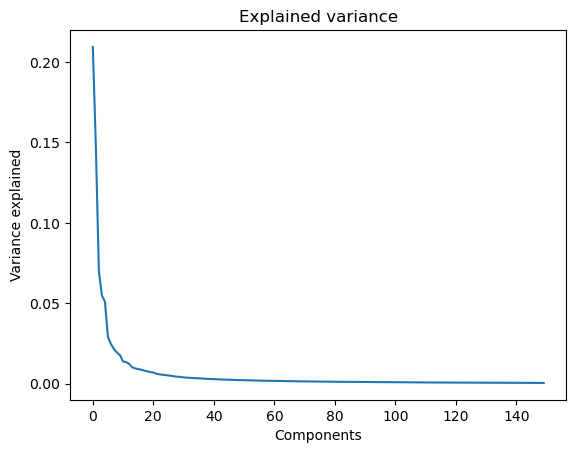

Mean explained variance: 0.0063408273


In [76]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel("Components")
plt.ylabel("Variance explained")
plt.title("Explained variance")
plt.show()
print("Mean explained variance:", np.mean(pca.explained_variance_ratio_))

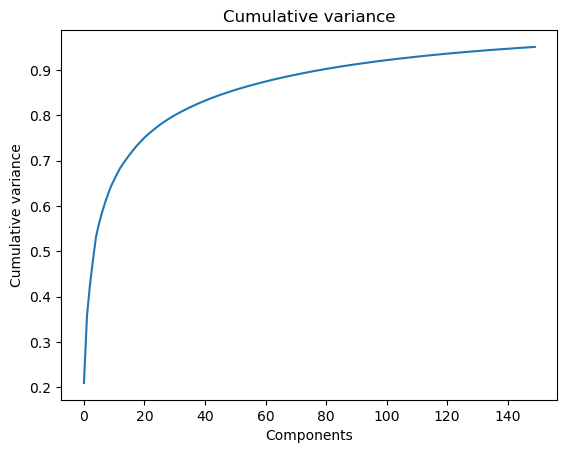

Accumulated variance: 0.9511242


In [77]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative variance")
plt.title("Cumulative variance")
plt.show()
print("Accumulated variance:", np.max(np.cumsum(pca.explained_variance_ratio_)))

**8.5** One interesting part of PCA is that it computes the average face, which can be interesting to examine. 

Plot the average face, using the method `mean_` of the PCA object.

**Hint:** The average face need to be reshaped in order to visualize it properly


<img src="images/mean_face.jpg" width=200, height=200>


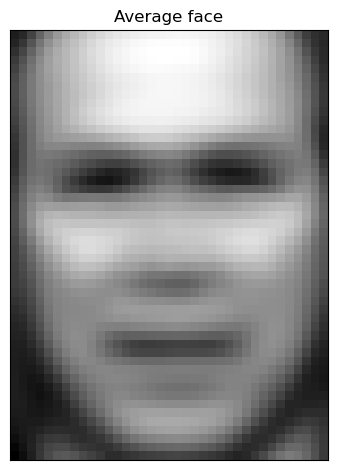

In [78]:
# pca.mean_ is not an image, but a 1-D array!!! We have to reshape it
mean_face = np.reshape(pca.mean_, (h,w))
plt.imshow(mean_face, cmap="gray")
plt.xticks([]); plt.yticks([]) # Off ticks

plt.title("Average face")
plt.tight_layout()
plt.show()

In [79]:
# Check its dimensions, max and min pixel value and type
print(mean_face.shape)
print(mean_face.dtype)
print(mean_face.max())
print(mean_face.min())

(50, 37)
float32
0.6900322
0.30998066


**8.6** Furhtermore, we can check all the principal components (i.e. eigenfaces) considering the corresponding importance. Visualize 30 principal eigenfaces.

<img src="images/eigenfaces.png" width=500, height=500>

Note that the base components are ordered by their importance. We see that the first few components seem to primarily take care of lighting conditions; the remaining components pull out certain identifying features: the nose, eyes, eyebrows, etc...

#### Note
We borrowed the idea from [here](https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html), we already used it this PCA part of this practicum, and we will keep using it.

EIGENFACES SHAPE (150, 50, 37)


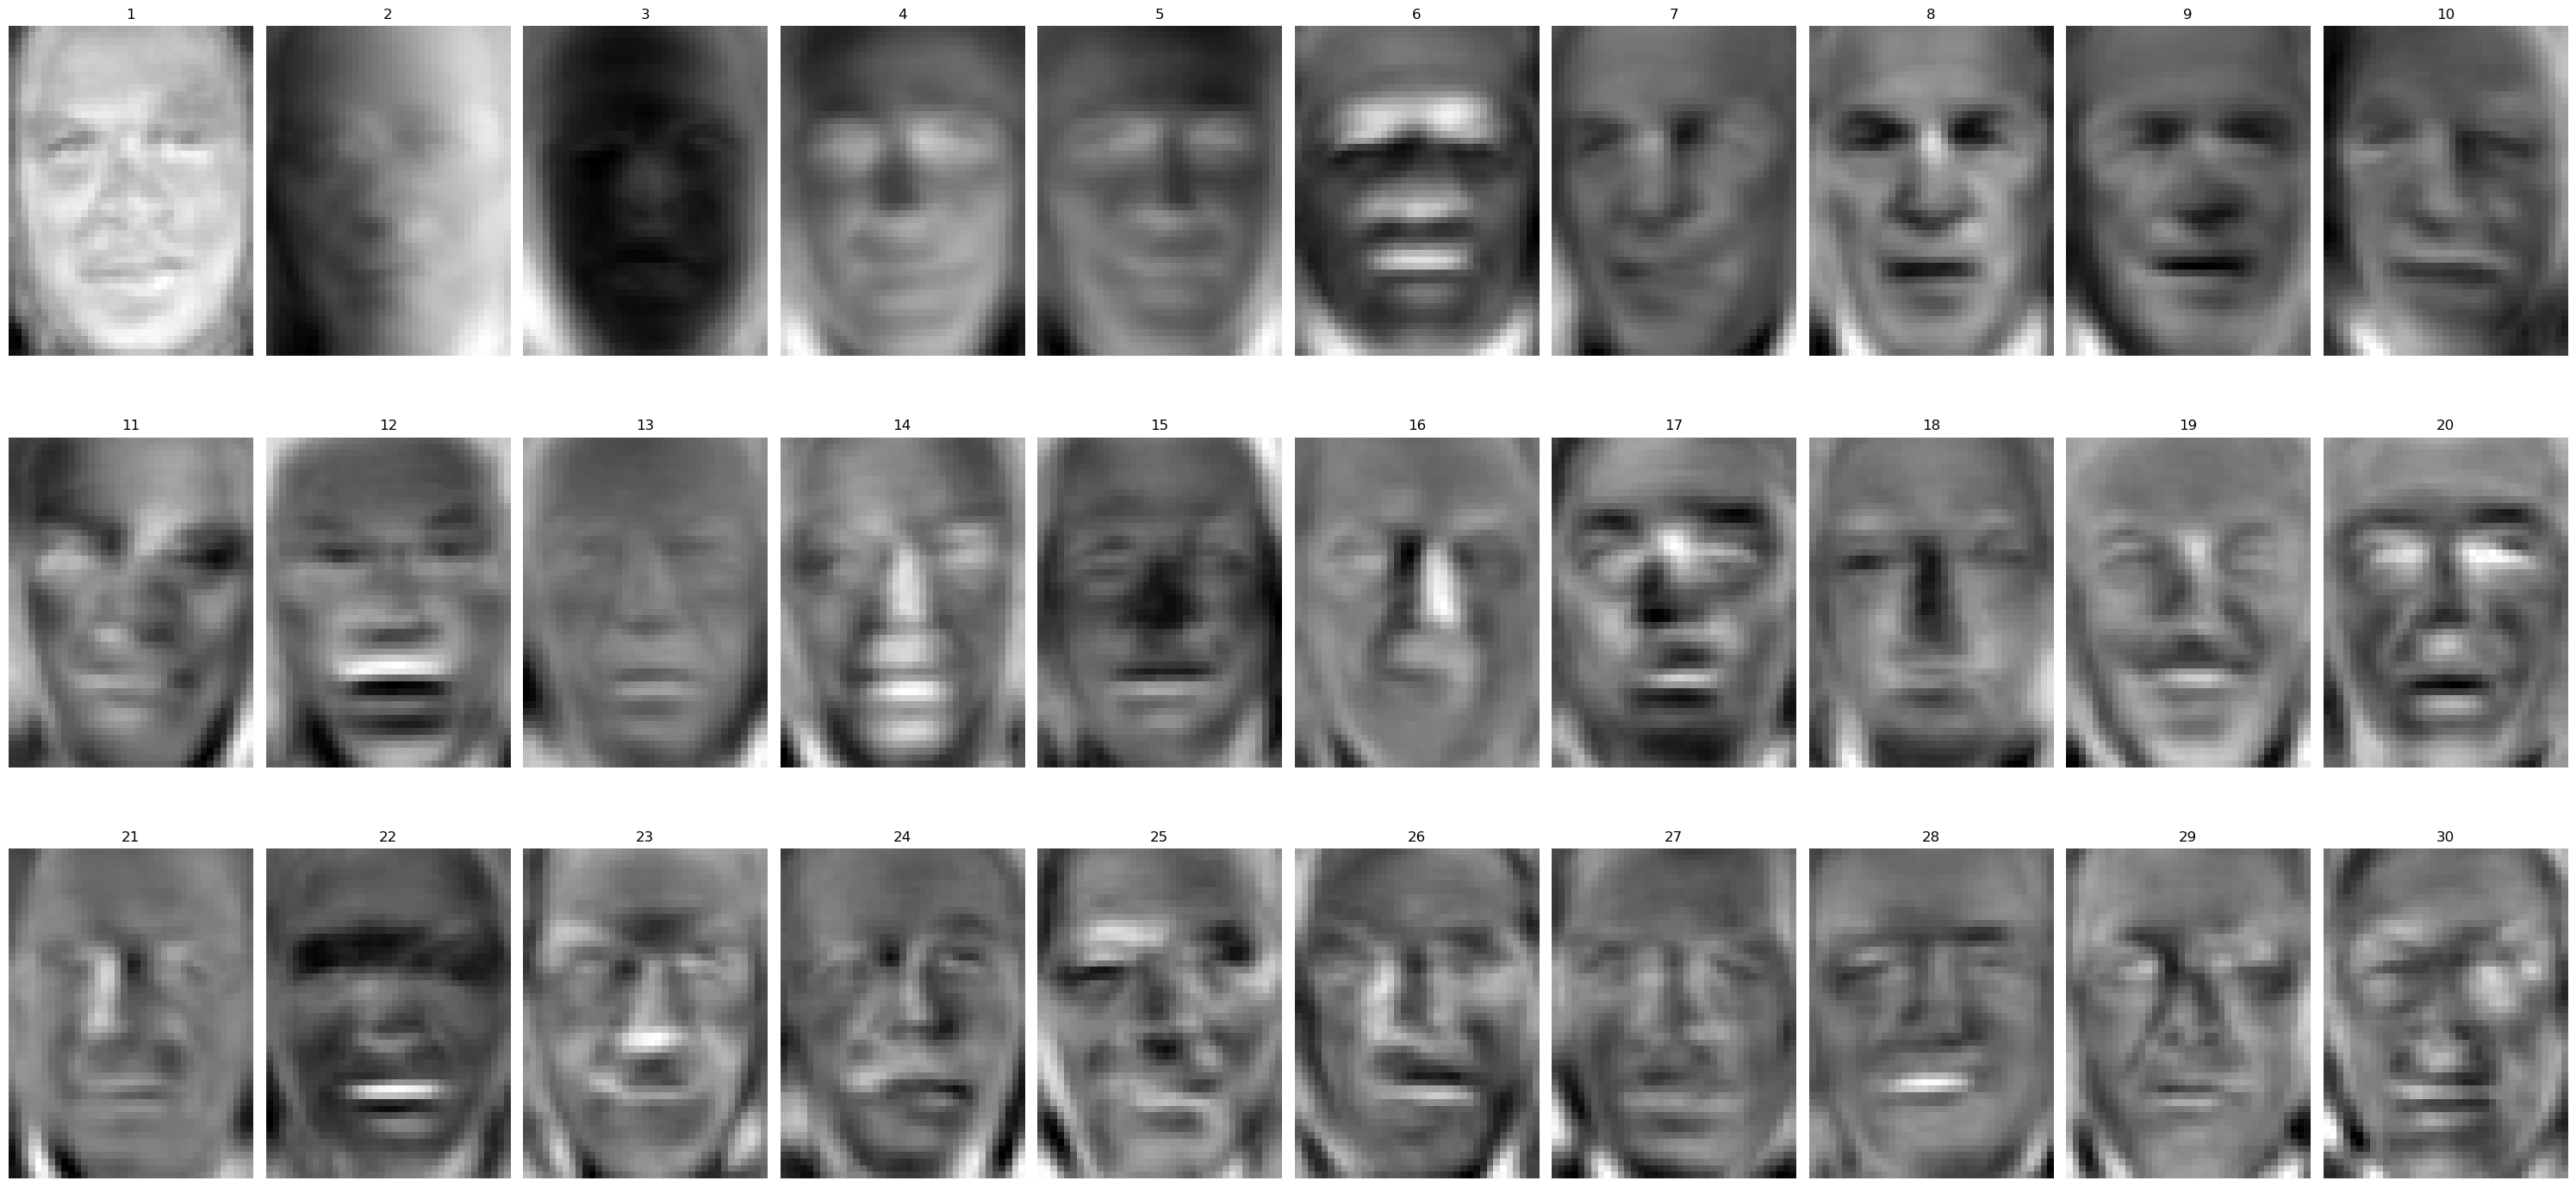

In [80]:
eigenfaces = pca.components_.reshape((n_components, h, w))
print("EIGENFACES SHAPE", eigenfaces.shape)

ncols = 10
n = 30

fig, axes = plt.subplots(n // ncols, ncols, figsize=(30,15))
ax = axes.ravel()

# We will only show first 30 eigenfaces
for i, image in enumerate(eigenfaces[:n]):
    ax[i].imshow(image, cmap="gray")
    ax[i].set_title(i+1)
    ax[i].axis('off')

plt.setp(ax, xticks=[], yticks=[]) # Off ticks
plt.tight_layout()
plt.show()

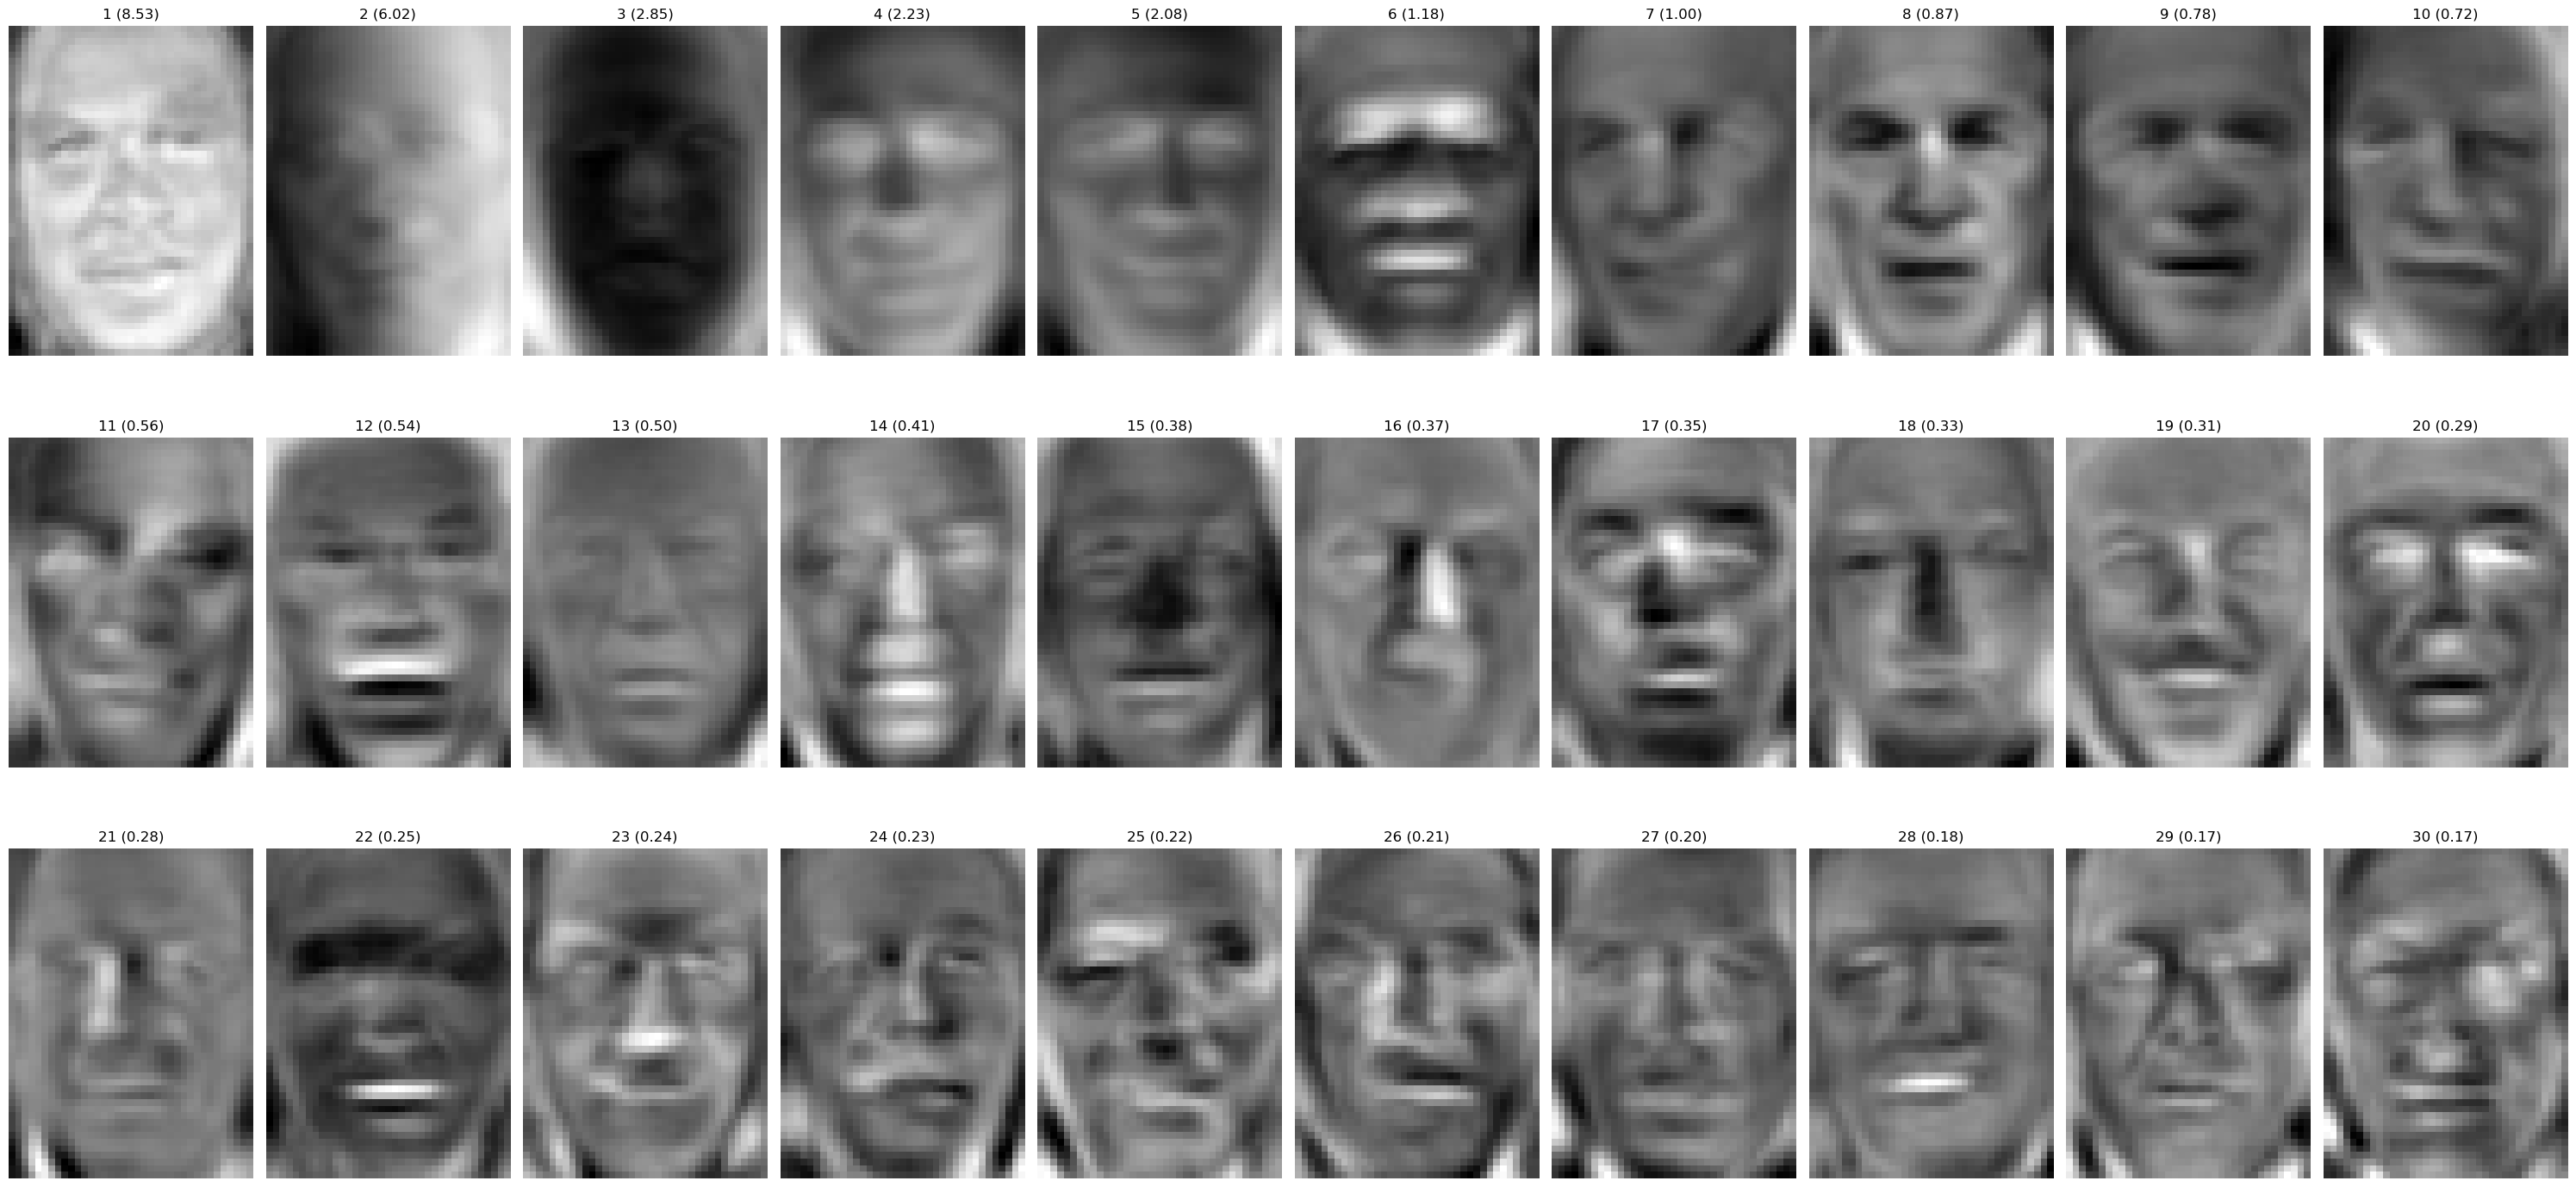

In [81]:
# But we could also obtain eigenfaces EXPLICITLY ordered by importance
imp = pca.explained_variance_
sorted_idxs = np.argsort(imp)[::-1]
eigensort = eigenfaces[sorted_idxs]

ncols = 10
n = 30
fig, axes = plt.subplots(n // ncols, ncols, figsize=(30, 15))
ax = axes.ravel()

for i, idx in enumerate(sorted_idxs[:n]):
    image = eigensort[idx]
    importance_value = imp[idx]
    ax[i].imshow(image, cmap="gray")
    ax[i].set_title(f"{i+1} ({importance_value:.2f})")
    ax[i].axis('off')

plt.setp(ax, xticks=[], yticks=[])  # Off ticks
plt.tight_layout()
plt.show()

**Note** clearly, it yields the same result.

**8.7** Project both the training and test set onto the PCA basis, using the method `transform()` of the PCA object.

These projected components correspond to factors in a linear combination of component images such that the combination approaches the original face. 

Choose one of the images and recompose from its first 10 most important corresponding eigenfaces. **Note that** we need to use the average face as the basis to agregate the rest of the components.


<img src="images/eigenfaces_image.PNG" width=300, height=300>

Example of output: 

<img src="images/recomposition_example.jpg" width=600, height=600>

In [82]:
print("Projecting the input data on the eigenfaces orthonormal basis")
t0 = time()
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("done in %0.3fs" % (time() - t0))

Projecting the input data on the eigenfaces orthonormal basis
done in 0.007s


In [83]:
help(pca.transform)

Help on method transform in module sklearn.decomposition._base:

transform(X) method of sklearn.decomposition._pca.PCA instance
    Apply dimensionality reduction to X.

    X is projected on the first principal components previously extracted
    from a training set.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        New data, where `n_samples` is the number of samples
        and `n_features` is the number of features.

    Returns
    -------
    X_new : array-like of shape (n_samples, n_components)
        Projection of X in the first principal components, where `n_samples`
        is the number of samples and `n_components` is the number of the components.



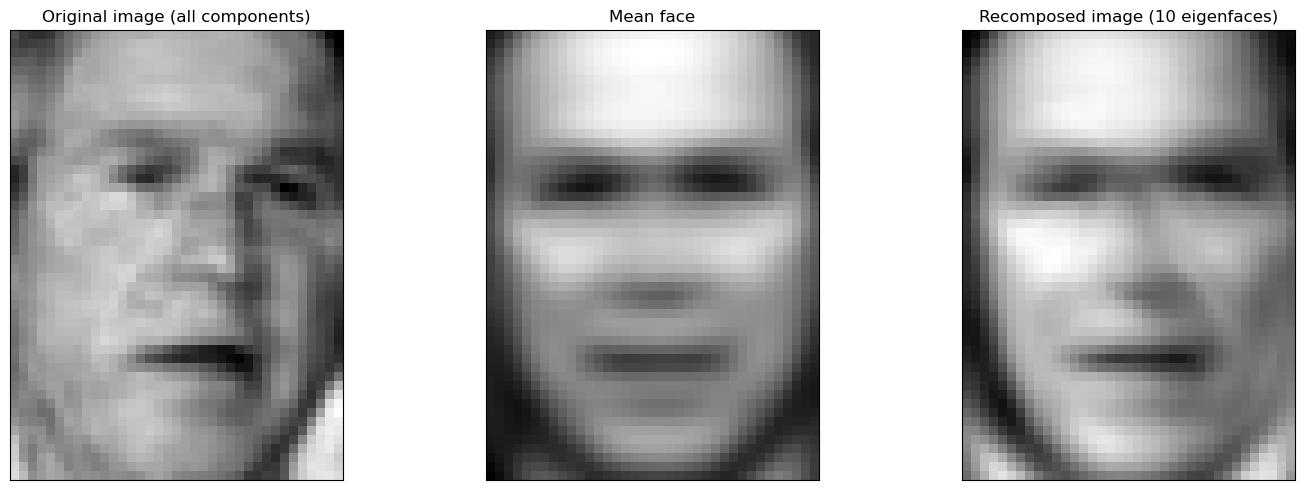

In [84]:
# Pick the first image's projection coefficients
# First 10 weights (coefficients)
weights = X_train_pca[0][:10]

# Select the first 10 eigenfaces (Already sorted by importance)
eigenfaces = pca.components_[:10]

# Normalize each eigenface (row-wise normalization)
eigenfaces /= np.linalg.norm(eigenfaces, axis=1, keepdims=True)

# Reconstruct the image using the first 10 eigenfaces
result = np.dot(weights, eigenfaces)  # Weighted sum of the first 10 eigenfaces
result += pca.mean_  # we need to use the average face as the basis to agregate the rest of the components
result = result.reshape((h, w))  # Reshape to original dimensions

# Reconstruct the image using all eigenfaces for comparison
face = pca.inverse_transform(X_train_pca[0]).reshape((h, w))

# Plot the images: original, mean face, and recomposed image
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original reconstructed image
axs[0].imshow(face, cmap='gray')
axs[0].set_title('Original image (all components)')

# Mean face
axs[1].imshow(mean_face, cmap='gray')
axs[1].set_title('Mean face')

# Reconstructed image using the first 10 eigenfaces
axs[2].imshow(result, cmap='gray')
axs[2].set_title('Recomposed image (10 eigenfaces)')

plt.setp(axs, xticks=[], yticks=[])  # Off ticks
plt.tight_layout()
plt.show()

## Train a classifier

**8.8** Train an Adaboost classifier using the PCA features. Show the results obtained with the test set.
Use the `score` method of the Adaboost model.

In [85]:
help(AdaBoostClassifier)

Help on class AdaBoostClassifier in module sklearn.ensemble._weight_boosting:

class AdaBoostClassifier(sklearn.utils._metadata_requests._RoutingNotSupportedMixin, sklearn.base.ClassifierMixin, BaseWeightBoosting)
 |  AdaBoostClassifier(
 |      estimator=None,
 |      *,
 |      n_estimators=50,
 |      learning_rate=1.0,
 |      algorithm='SAMME.R',
 |      random_state=None
 |  )
 |
 |  An AdaBoost classifier.
 |
 |  An AdaBoost [1]_ classifier is a meta-estimator that begins by fitting a
 |  classifier on the original dataset and then fits additional copies of the
 |  classifier on the same dataset but where the weights of incorrectly
 |  classified instances are adjusted such that subsequent classifiers focus
 |  more on difficult cases.
 |
 |  This class implements the algorithm based on [2]_.
 |
 |  Read more in the :ref:`User Guide <adaboost>`.
 |
 |  .. versionadded:: 0.14
 |
 |  Parameters
 |  ----------
 |  estimator : object, default=None
 |      The base estimator from whi

In [86]:
clf = AdaBoostClassifier(n_estimators=100, random_state=0, learning_rate=1.0)

In [87]:
%%time

# We do not need to transform y
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
score = clf.score(X_test_pca, y_test)
print("SCORE:", score)

SCORE: 0.6257309941520468
CPU times: user 2.39 s, sys: 8.28 ms, total: 2.4 s
Wall time: 2.4 s


**8.9** We can quantify this effectiveness using one of several measures from sklearn.metrics. First we can do the classification report, which shows the precision, recall and other measures of the “goodness” of the classification.

*sklearn.metrics.classification_report(y_true, y_pred, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')*

*Please, check the parameters and returned value by ``classification_report()`` before continuing.*

Print the classification report obtained during the training of the Adaboost model.

In [88]:
help(classification_report)

Help on function classification_report in module sklearn.metrics._classification:

classification_report(
    y_true,
    y_pred,
    *,
    labels=None,
    target_names=None,
    sample_weight=None,
    digits=2,
    output_dict=False,
    zero_division='warn'
)
    Build a text report showing the main classification metrics.

    Read more in the :ref:`User Guide <classification_report>`.

    Parameters
    ----------
    y_true : 1d array-like, or label indicator array / sparse matrix
        Ground truth (correct) target values.

    y_pred : 1d array-like, or label indicator array / sparse matrix
        Estimated targets as returned by a classifier.

    labels : array-like of shape (n_labels,), default=None
        Optional list of label indices to include in the report.

    target_names : array-like of shape (n_labels,), default=None
        Optional display names matching the labels (same order).

    sample_weight : array-like of shape (n_samples,), default=None
        Sa

In [89]:
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Colin Powell       0.68      0.61      0.64        71
  Donald Rumsfeld       0.57      0.36      0.44        36
    George W Bush       0.59      0.85      0.70       159
Gerhard Schroeder       0.79      0.33      0.47        33
       Tony Blair       0.80      0.28      0.41        43

         accuracy                           0.63       342
        macro avg       0.69      0.49      0.53       342
     weighted avg       0.65      0.63      0.60       342



In [90]:
# Extra from sci-kit learn documentation
from sklearn.metrics import ConfusionMatrixDisplay
help(ConfusionMatrixDisplay)

Help on class ConfusionMatrixDisplay in module sklearn.metrics._plot.confusion_matrix:

class ConfusionMatrixDisplay(builtins.object)
 |  ConfusionMatrixDisplay(confusion_matrix, *, display_labels=None)
 |
 |  Confusion Matrix visualization.
 |
 |  It is recommend to use
 |  :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_estimator` or
 |  :func:`~sklearn.metrics.ConfusionMatrixDisplay.from_predictions` to
 |  create a :class:`ConfusionMatrixDisplay`. All parameters are stored as
 |  attributes.
 |
 |  Read more in the :ref:`User Guide <visualizations>`.
 |
 |  Parameters
 |  ----------
 |  confusion_matrix : ndarray of shape (n_classes, n_classes)
 |      Confusion matrix.
 |
 |  display_labels : ndarray of shape (n_classes,), default=None
 |      Display labels for plot. If None, display labels are set from 0 to
 |      `n_classes - 1`.
 |
 |  Attributes
 |  ----------
 |  im_ : matplotlib AxesImage
 |      Image representing the confusion matrix.
 |
 |  text_ : ndarray of shape 

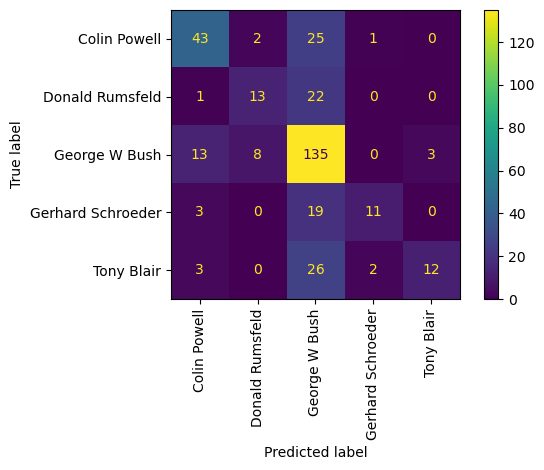

In [91]:
ConfusionMatrixDisplay.from_estimator(
    clf, X_test_pca, y_test, display_labels=target_names, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()

## Recognize a new face example using the learned model

**8.10** Try your model using the test set. 

Predict the labels using the Adaboost model, with and without PCA, and plot the images with the corresponding label as title.

<img src="images/prediction.png" width=300 height = 300>

In [92]:
# Adapted from sci-kit learn documentation

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap="gray")
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

def title(y_pred, y_test, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(" ", 1)[-1]
    true_name = target_names[y_test[i]].rsplit(" ", 1)[-1]
    return "predicted: %s\ntrue:      %s" % (pred_name, true_name)

### Predictions with PCA

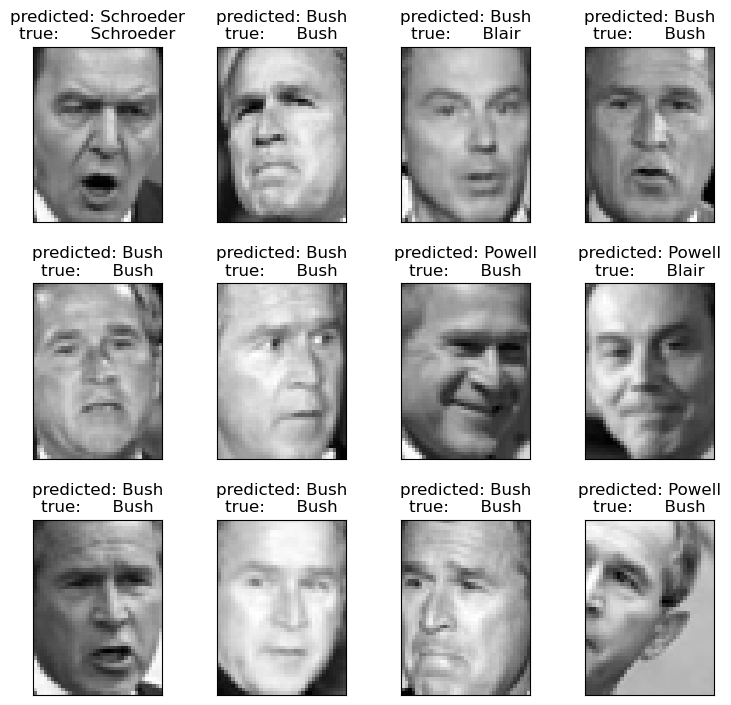

In [93]:
prediction_titles = [
    title(y_pred, y_test, target_names, i) for i in range(y_pred.shape[0])
]

plot_gallery(X_test, prediction_titles, h, w)

## Prediction without PCA

In [94]:
clf = AdaBoostClassifier(n_estimators=100, random_state=0, learning_rate=1.0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
score = clf.score(X_test, y_test)
print("SCORE:", score) # Score is much lower

SCORE: 0.6345029239766082


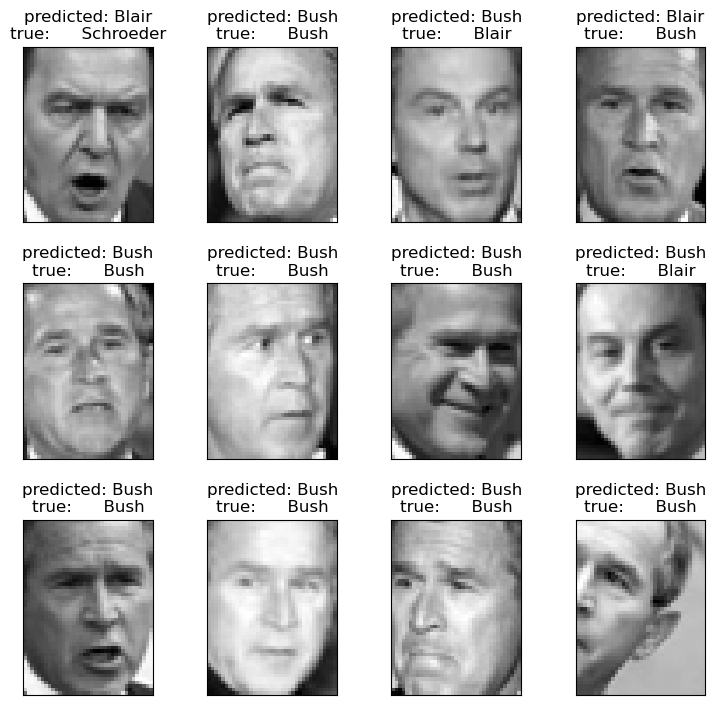

In [95]:
prediction_titles = [
    title(y_pred, y_test, target_names, i) for i in range(y_pred.shape[0])
]

plot_gallery(X_test, prediction_titles, h, w)

## Some observations
1. PCA improves accuracy in the prediction. 
2. Bush's accuracy is remarkably high. It is true that it is predicted many more times than any other candidate, but there is not any misplaced Bush's photo _in these two samples_, both with and without PCA (i.e. if `true` value is Bush, every prediction will be Bush).

# Appendix

Instead of `AdaBoost`, [here](https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html) `RandomizedSearchCV` is used. As we will see in the results, results seem more accurate.

### Comparison: AdaBoost vs. RandomizedSearchCV

#### 1. **AdaBoost**
- AdaBoost combines multiple weak learners to create a strong learner.
- Focuses on misclassified examples by assigning higher weights to them.
- **Advantages**:
  - Simple and effective for many classification tasks.
  - Handles both binary and multi-class classification.
  - Can achieve high accuracy if the base estimators are well-chosen.
- **Disadvantages**:
  - Sensitive to noisy data and outliers.
  - May overfit if the number of estimators is too high.

#### 2. **RandomizedSearchCV**
- RandomizedSearchCV searches across a specified parameter grid using random combinations. It samples a fixed number of parameter settings randomly, which reduces computation time.
- **Advantages**:
  - Efficient when searching over large parameter spaces.
  - Can improve model performance by finding near-optimal hyperparameters.
  - Reduces training time compared to an exhaustive grid search.
- **Disadvantages**:
  - Requires careful selection of parameter ranges.
  - Results may vary between runs unless the random seed is fixed.

#### Conclusions
- AdaBoost is better suited for boosting model accuracy directly on a task.
- RandomizedSearchCV is better when fine-tuning parameters to achieve optimal performance across models.
- If computational resources allow, using RandomizedSearchCV to optimize AdaBoost hyperparameters often yields the best results.


In [96]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [97]:
print("Fitting the classifier to the training set")
t0 = time()
param_grid = {
    "C": loguniform(1e3, 1e5),
    "gamma": loguniform(1e-4, 1e-1),
}
clf = RandomizedSearchCV(
    SVC(kernel="rbf", class_weight="balanced"), param_grid, n_iter=10
)
clf = clf.fit(X_train_pca, y_train)
print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
print(clf.best_estimator_)
print("SCORE:", clf.score(X_test_pca, y_test)) # Score is much higher than with AdaBoost

Fitting the classifier to the training set
done in 4.762s
Best estimator found by grid search:
SVC(C=np.float64(41122.134918584554), class_weight='balanced',
    gamma=np.float64(0.0032700164708871823))
SCORE: 0.8567251461988304


Predicting people's names on the test set
done in 0.048s
                   precision    recall  f1-score   support

     Colin Powell       0.80      0.92      0.86        71
  Donald Rumsfeld       0.86      0.69      0.77        36
    George W Bush       0.85      0.92      0.88       159
Gerhard Schroeder       0.96      0.79      0.87        33
       Tony Blair       0.91      0.72      0.81        43

         accuracy                           0.86       342
        macro avg       0.88      0.81      0.84       342
     weighted avg       0.86      0.86      0.85       342



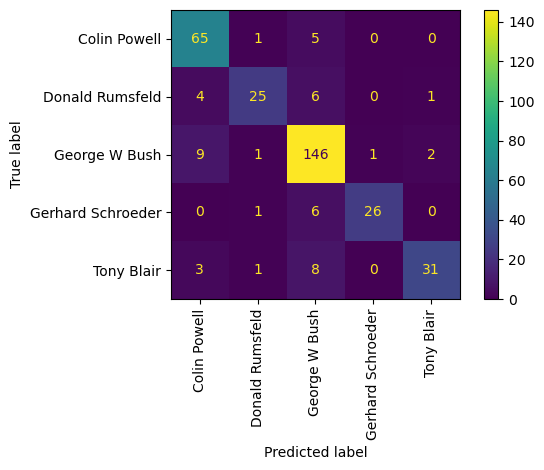

In [98]:
print("Predicting people's names on the test set")
t0 = time()
y_pred = clf.predict(X_test_pca)
print("done in %0.3fs" % (time() - t0))

print(classification_report(y_test, y_pred, target_names=target_names))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test_pca, y_test, display_labels=target_names, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()

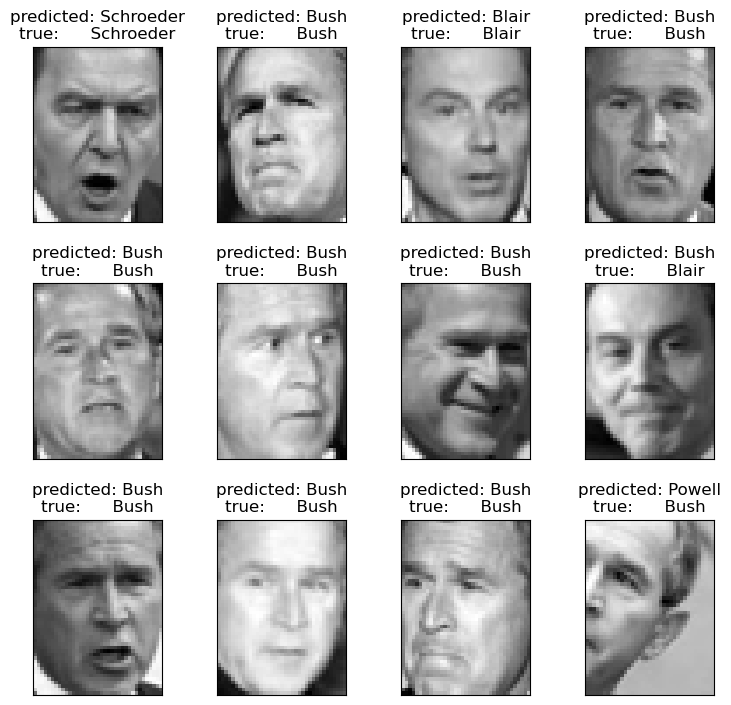

In [99]:
prediction_titles = [
    title(y_pred, y_test, target_names, i) for i in range(y_pred.shape[0])
]

plot_gallery(X_test, prediction_titles, h, w)

# Appendix 2

In case the library for exercise 1 does not work for you, here is the function that will create the filters for you:

In [100]:
"""
Functions needed to create the Leung-Malik (LM) filter bank
"""
import numpy as np
import cv2
import matplotlib.pyplot as plt

def gaussian1d(sigma, mean, x, ord):
    x = np.array(x)
    x_ = x - mean
    var = sigma**2

    # Gaussian Function
    g1 = (1/np.sqrt(2*np.pi*var))*(np.exp((-1*x_*x_)/(2*var)))

    if ord == 0:
        g = g1
        return g
    elif ord == 1:
        g = -g1*((x_)/(var))
        return g
    else:
        g = g1*(((x_*x_) - var)/(var**2))
        return g

def gaussian2d(sup, scales):
    var = scales * scales
    shape = (sup,sup)
    n,m = [(i - 1)/2 for i in shape]
    x,y = np.ogrid[-m:m+1,-n:n+1]
    g = (1/np.sqrt(2*np.pi*var))*np.exp( -(x*x + y*y) / (2*var) )
    return g

def log2d(sup, scales):
    var = scales * scales
    shape = (sup,sup)
    n,m = [(i - 1)/2 for i in shape]
    x,y = np.ogrid[-m:m+1,-n:n+1]
    g = (1/np.sqrt(2*np.pi*var))*np.exp( -(x*x + y*y) / (2*var) )
    h = g*((x*x + y*y) - var)/(var**2)
    return h

def makefilter(scale, phasex, phasey, pts, sup):

    gx = gaussian1d(3*scale, 0, pts[0,...], phasex)
    gy = gaussian1d(scale,   0, pts[1,...], phasey)

    image = gx*gy

    image = np.reshape(image,(sup,sup))
    return image

def makeLMfilters():
    sup     = 49
    scalex  = np.sqrt(2) * np.array([1,2,3])
    norient = 6
    nrotinv = 12

    nbar  = len(scalex)*norient
    nedge = len(scalex)*norient
    nf    = nbar+nedge+nrotinv
    F     = np.zeros([sup,sup,nf])
    hsup  = (sup - 1)/2

    x = [np.arange(-hsup,hsup+1)]
    y = [np.arange(-hsup,hsup+1)]

    [x,y] = np.meshgrid(x,y)

    orgpts = [x.flatten(), y.flatten()]
    orgpts = np.array(orgpts)

    count = 0
    for scale in range(len(scalex)):
        for orient in range(norient):
            angle = (np.pi * orient)/norient
            c = np.cos(angle)
            s = np.sin(angle)
            rotpts = [[c+0,-s+0],[s+0,c+0]]
            rotpts = np.array(rotpts)
            rotpts = np.dot(rotpts,orgpts)
            F[:,:,count] = makefilter(scalex[scale], 0, 1, rotpts, sup)
            F[:,:,count+nedge] = makefilter(scalex[scale], 0, 2, rotpts, sup)
            count = count + 1

    count = nbar+nedge
    scales = np.sqrt(2) * np.array([1,2,3,4])

    for i in range(len(scales)):
        F[:,:,count]   = gaussian2d(sup, scales[i])
        count = count + 1

    for i in range(len(scales)):
        F[:,:,count] = log2d(sup, scales[i])
        count = count + 1

    for i in range(len(scales)):
        F[:,:,count] = log2d(sup, 3*scales[i])
        count = count + 1

    return F

ModuleNotFoundError: No module named 'cv2'